## STR analysis in TSS/TES 3' Cleavage Sites

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
domain_colors = {
                'Viruses': '#B2EBEB',
                'Eukaryota': '#FFB2B2',
                'Archaea': '#B2B2FF',
                'Bacteria': '#B2D8B2'
               
}
kingdom_color_palette = {
                          "Viruses": "#87C4C4",
                         "Bacteria": "#0FBF2D",
                         "Archaea": "#7B7BED",
                         "Fungi": "#4D325E",
                         "Plantae": "#B50996",
                        "Animalia": "#9BBA2D",
                        "Protista": "#C78F5B"
                        }
colors = {
    'Virus': '#66C2A5',
    'Bacteria': '#FC8D62',
    'Eukaryota': '#8DA0CB',
    'Archaea': '#E78AC3'
}

kingdom_color_palette = {'Viruses': '#6bb5c7',
                     'Bacteria': '#0fbf2d',
                     'Archaea': '#b2b2ff',
                     'Fungi': '#4d325e',
                     'Plantae': '#b50996',
                     'Eubacteria': '#0fbf2d',
                     'Animalia': '#9bba2d',
                     'Protista': '#c78f5b',
                    'Thermoproteati': '#380e8c',
                     'Promethearchaeti': '#672fd6',
                     'Nanobdellati': '#8154eb',
                     'Methanobacteriati': '#1fc46a',
                     'Fusobacteriati': '#94cc2d',
                     'Bacillati': '#bbd61e',
                     'Thermotogati': '#7b7bed'}

domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#b2d8b2',
                'Viruses': '#229ad6',
}

color_templates = {'template': {
                                'Viruses': '#229ad6',
                                'Bacteria': '#0fbf2d',
                                'Eukaryota': '#edc41f',
                                'Archaea': '#b2b2ff'
                                },
                   'non-template': {'Viruses': '#66C28B',
                                    'Bacteria': '#FC8D62',
                                   'Eukaryota': '#6CA5C4',
                                   'Archaea': '#9A3BD1'},
                   }

## Coverage

In [211]:
import re

def max_STR_coverage(seq: str) -> float:
    seq = seq.upper()
    str_lengths = range(1, 9)  # 1 to 8
    f = lambda n: 2 if n >= 3 else (3 if n == 2 else 6) 
    patterns = [r"(([ATGC]{%s}?)\2{%s,})" % (n, f(n)) for n in str_lengths]
    patterns.append(r"(([ATGC]{9,}?)\2{2,})")  # {9,}
    coverage = [0 for _ in range(len(seq))]
    for pattern in patterns:
        matches = re.finditer(pattern, seq)
        for match in matches:
            start = match.start()
            end = match.end()
            motif = match.group(1)
            full_match = match.group(2)
            print(start, end, motif, full_match)
            for pos in range(start, end):
                coverage[pos] = 1
                
    # if motif_counter:
    #    max_occupied = max(motif_counter.values())
    #    return max_occupied / len(seq)
    return (1e2 * sum(coverage) / len(seq)) // 20

max_STR_coverage("GAGAGAGAG")

0 8 GAGAGAGA GA


4.0

## Coverage

In [44]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm

indir = Path("../STR_RTR/coverage/coverage_out_STR/partition_sru").resolve()
files = [file for file in indir.glob("coverage_bucket_*_False.txt") if file.is_file()]
coverage_df_sru = []
coverage_df = []

for file in tqdm(files):
    temp_df = pd.read_table(file).query("biotype == '.'").drop(columns=['biotype'])
    coverage_df_sru.append(temp_df.query("sru != 'generic'"))
    coverage_df.append(temp_df.query("sru == 'generic'"))
    
coverage_df = pd.concat(coverage_df, ignore_index=True)
coverage_df_sru = pd.concat(coverage_df_sru, ignore_index=True)
coverage_df

100%|██████████| 100/100 [00:09<00:00, 10.43it/s]


,compartment,totalHits,totalCompartments,totalCompartmentsUnmerged,overlappingBp,compartmentLength,avg_coverage,median_coverage,std_coverage,q975_coverage,q025_coverage,min_coverage,max_coverage,atLeastOne,atLeastOneUnmerged,perc_atLeastOne,coverage,sru,#assembly_accession
0,Genome,94,1,1,1141,3551206,321.30,321.3,NaN,321.3,321.3,321.3,321.3,1,1,100.00,321.30,generic,GCA_000219855.1
1,Gene,85,2961,3821,1026,3150494,326.27,0.0,2848.91,3131.5,0.0,0.0,74074.1,82,135,2.77,325.66,generic,GCA_000219855.1
2,Exon,85,2961,3821,1026,3150494,326.27,0.0,2848.91,3131.5,0.0,0.0,74074.1,82,135,2.77,325.66,generic,GCA_000219855.1
3,CDS,85,2895,3754,1026,3123418,333.71,0.0,2880.78,3526.3,0.0,0.0,74074.1,82,135,2.83,328.49,generic,GCA_000219855.1
4,Genome,504,1,1,5923,6818030,868.70,868.7,NaN,868.7,868.7,868.7,868.7,1,1,100.00,868.73,generic,GCA_000473745.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440380,CDS,291,4857,5217,3674,4438457,873.28,0.0,5366.53,11976.0,0.0,0.0,146789.0,274,309,5.64,827.77,generic,GCF_963665995.1
440381,Genome,231,1,1,2762,3672159,752.10,752.1,NaN,752.1,752.1,752.1,752.1,1,1,100.00,752.15,generic,GCF_963678195.1
440382,Gene,208,2867,3536,2509,3349736,801.91,0.0,4178.45,10840.1,0.0,0.0,81967.2,192,287,6.70,749.01,generic,GCF_963678195.1
440383,Exon,208,2868,3537,2509,3349735,801.63,0.0,4177.75,10840.1,0.0,0.0,81967.2,192,287,6.69,749.01,generic,GCF_963678195.1


In [33]:
from pathlib import Path
TOL_PATH = Path("/storage/group/izg5139/default/nicole/STR_RTR/scripts/scripts_restore_20250723/assembly_summary_with_tree.csv.gz")
tree_of_life = pd.read_table(TOL_PATH)
tree_of_life

/tmp/ipykernel_112069/3009699945.py:3: DtypeWarning: Columns (13,14,15,25) have mixed types. Specify dtype option on import or set low_memory=False.
  tree_of_life = pd.read_table(TOL_PATH)


,#assembly_accession,taxid,species_taxid,organism_name,infraspecific_name,isolate,assembly_level,ftp_path,assembly_type,group,...,tax_id,domain,phylum,class,order,family,genus,species,kingdom,subkingdom
0,GCF_000762265.1,2162,2162,Methanobacterium formicicum,strain=BRM9,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,haploid,archaea,...,2162.0,Archaea,Methanobacteriota,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Methanobacterium,Methanobacterium formicicum,Methanobacteriati,NaN
1,GCF_001458655.1,2162,2162,Methanobacterium formicicum,na,Mb9,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,haploid,archaea,...,2162.0,Archaea,Methanobacteriota,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Methanobacterium,Methanobacterium formicicum,Methanobacteriati,NaN
2,GCF_002813085.1,2173,2173,Methanobrevibacter smithii,strain=KB11,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,haploid,archaea,...,2173.0,Archaea,Methanobacteriota,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Methanobrevibacter,Methanobrevibacter smithii,Methanobacteriati,NaN
3,GCF_022846155.1,2173,2173,Methanobrevibacter smithii,strain=CE91-St67,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,haploid,archaea,...,2173.0,Archaea,Methanobacteriota,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Methanobrevibacter,Methanobrevibacter smithii,Methanobacteriati,NaN
4,GCF_022846175.1,2173,2173,Methanobrevibacter smithii,strain=CE91-St68,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,haploid,archaea,...,2173.0,Archaea,Methanobacteriota,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Methanobrevibacter,Methanobrevibacter smithii,Methanobacteriati,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171379,GCA_037114785.1,3127874,3127874,Enterococcus phage vB_Efa_ZAT1,na,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/0...,haploid,viral,...,3127874.0,Viruses,Uroviricota,Caudoviricetes,NaN,NaN,Efquatrovirus,Enterococcus phage vB_Efa_ZAT1,Heunggongvirae,NaN
171380,GCA_037114795.1,3127946,3127946,Bacillus phage vB_Bsu_hmny1,na,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/0...,haploid,viral,...,3127946.0,Viruses,Uroviricota,Caudoviricetes,NaN,Salasmaviridae,Beecentumtrevirus,Bacillus phage vB_Bsu_hmny1,Heunggongvirae,NaN
171381,GCA_037114805.1,3127947,3127947,Bacillus phage vB_Bsu_hmny2,na,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/0...,haploid,viral,...,3127947.0,Viruses,Uroviricota,Caudoviricetes,NaN,Salasmaviridae,Beecentumtrevirus,Bacillus phage vB_Bsu_hmny2,Heunggongvirae,NaN
171382,GCA_037114815.1,3127948,3127948,Vibrio phage Va-ZX-1,na,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/0...,haploid,viral,...,3127948.0,Viruses,Uroviricota,Caudoviricetes,NaN,Autographiviridae,Kaohsiungvirus,Kaohsiungvirus VaZX1,Heunggongvirae,NaN


In [ ]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm

def load_coverage(pattern: str, partition_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    indir = Path(f"../STR_RTR/coverage/coverage_out_{pattern}").resolve()
    if partition_col is not None:
        indir = indir / f"partition_{partition_col}"
    assert indir.is_dir()
    files = [file for file in indir.glob("coverage_bucket_*_False.txt") if file.is_file()]
    coverage_df_partition = []
    coverage_df = []
    for file in tqdm(files):
        temp_df = pd.read_table(file).query("biotype == '.'").drop(columns=['biotype'])
        if partition_col is not None:
            coverage_df_partition.append(temp_df.query(f"{partition_col} != 'generic'"))
            temp_df = temp_df.query(f"{partition_col} == 'generic'")
        coverage_df.append(temp_df)
        
    coverage_df = pd.concat(coverage_df, ignore_index=True)
    
    if partition_col:
        coverage_df_partition = pd.concat(coverage_df_partition, ignore_index=True)
    coverage_df = coverage_df.merge(
                                        tree_of_life[["#assembly_accession", "species_taxid", "domain", "kingdom", "phylum"]],
                                        on="#assembly_accession"
    )
    if partition_col:
        coverage_df_partition = coverage_df_partition.merge(
                                        tree_of_life[["#assembly_accession", "species_taxid", "domain", "kingdom", "phylum"]],
                                        on="#assembly_accession"
        )
        coverage_df_partition.loc[:, "coverage"] = coverage_df_partition["coverage"] / 1e3

    coverage_df.loc[:, "coverage"] = coverage_df["coverage"] / 1e3
    return coverage_df, coverage_df_partition

In [35]:
pattern = "STR"
coverage_STR_df, coverage_STR_df_sru = load_coverage(pattern, partition_col="sru")
coverage_STR_df

100%|██████████| 100/100 [00:06<00:00, 14.83it/s]


,compartment,totalHits,totalCompartments,totalCompartmentsUnmerged,overlappingBp,compartmentLength,avg_coverage,median_coverage,std_coverage,q975_coverage,...,atLeastOne,atLeastOneUnmerged,perc_atLeastOne,coverage,sru,#assembly_accession,species_taxid,domain,kingdom,phylum
0,Genome,94,1,1,1141,3551206,321.30,321.3,NaN,321.3,...,1,1,100.00,0.32130,generic,GCA_000219855.1,53633,Bacteria,Bacillati,Bacillota
1,Gene,85,2961,3821,1026,3150494,326.27,0.0,2848.91,3131.5,...,82,135,2.77,0.32566,generic,GCA_000219855.1,53633,Bacteria,Bacillati,Bacillota
2,Exon,85,2961,3821,1026,3150494,326.27,0.0,2848.91,3131.5,...,82,135,2.77,0.32566,generic,GCA_000219855.1,53633,Bacteria,Bacillati,Bacillota
3,CDS,85,2895,3754,1026,3123418,333.71,0.0,2880.78,3526.3,...,82,135,2.83,0.32849,generic,GCA_000219855.1,53633,Bacteria,Bacillati,Bacillota
4,Genome,504,1,1,5923,6818030,868.70,868.7,NaN,868.7,...,1,1,100.00,0.86873,generic,GCA_000473745.3,287,Bacteria,Pseudomonadati,Pseudomonadota
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440380,CDS,291,4857,5217,3674,4438457,873.28,0.0,5366.53,11976.0,...,274,309,5.64,0.82777,generic,GCF_963665995.1,3040204,Bacteria,Bacillati,Cyanobacteriota
440381,Genome,231,1,1,2762,3672159,752.10,752.1,NaN,752.1,...,1,1,100.00,0.75215,generic,GCF_963678195.1,225298,Bacteria,Pseudomonadati,Pseudomonadota
440382,Gene,208,2867,3536,2509,3349736,801.91,0.0,4178.45,10840.1,...,192,287,6.70,0.74901,generic,GCF_963678195.1,225298,Bacteria,Pseudomonadati,Pseudomonadota
440383,Exon,208,2868,3537,2509,3349735,801.63,0.0,4177.75,10840.1,...,192,287,6.69,0.74901,generic,GCF_963678195.1,225298,Bacteria,Pseudomonadati,Pseudomonadota


In [ ]:
# MR
coverage_MR_df_spacer_length_reduced = coverage_MR_df_spacer_length.groupby(["species_taxid", "compartment", "spacer_length"], as_index=False)\
                                                        .agg({"coverage": "mean",
                                                              "phylum": "first",
                                                              "kingdom": "first",
                                                              "domain": "first",
                                                             })

coverage_MR_df_reduced = coverage_MR_df.groupby(["species_taxid", "compartment"], as_index=False)\
                                                        .agg({"coverage": "mean",
                                                              "phylum": "first",
                                                              "kingdom": "first",
                                                              "domain": "first",
                                                             })


In [36]:


# STR
coverage_STR_df_sru_reduced = coverage_STR_df_sru.groupby(["species_taxid", "compartment", "sru"], as_index=False)\
                                                        .agg({"coverage": "mean",
                                                              "phylum": "first",
                                                              "kingdom": "first",
                                                              "domain": "first",
                                                             })

coverage_STR_df_reduced = coverage_STR_df.groupby(["species_taxid", "compartment"], as_index=False)\
                                                        .agg({"coverage": "mean",
                                                              "phylum": "first",
                                                              "kingdom": "first",
                                                              "domain": "first",
                                                             })
coverage_STR_df_sru_reduced

,species_taxid,compartment,sru,coverage,phylum,kingdom,domain
0,7,CDS,1,0.00588,Pseudomonadota,Pseudomonadati,Bacteria
1,7,CDS,2,0.23109,Pseudomonadota,Pseudomonadati,Bacteria
2,7,CDS,3,1.13003,Pseudomonadota,Pseudomonadati,Bacteria
3,7,CDS,4,0.28319,Pseudomonadota,Pseudomonadati,Bacteria
4,7,CDS,5,0.01891,Pseudomonadota,Pseudomonadati,Bacteria
...,...,...,...,...,...,...,...
542870,3128044,Genome,3,0.16100,Uroviricota,Heunggongvirae,Viruses
542871,3128044,Genome,4,0.07155,Uroviricota,Heunggongvirae,Viruses
542872,3128044,Genome,5,0.08944,Uroviricota,Heunggongvirae,Viruses
542873,3128044,Genome,6,0.10733,Uroviricota,Heunggongvirae,Viruses


In [46]:
coverage_df.loc[:, "coverage"] = coverage_df["coverage"] / 1e3
coverage_df_sru.loc[:, "coverage"] = coverage_df_sru["coverage"] / 1e3

In [266]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_rgba
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from statannotations.Annotator import Annotator

def blend_with_white(hex_color, alpha):
    rgb = mcolors.to_rgb(hex_color)
    blended = [1 - alpha + c * alpha for c in rgb]  # blend toward white
    return mcolors.to_hex(blended)
    
def plot_domain_level_coverage(coverage_df_partition: pd.DataFrame,
                               partition_col: str, 
                               pattern: str,
                               figsize=(20, 12), 
                               hspace=0.4, 
                               alpha=1.0, 
                               wspace=0.2, 
                               capsize=0.4,
                               saturation=0.6,
                               edgecolor='black',
                               linewidth=1.0,
                               width=0.7,
                               palette_=None,
                               rect_height=0.05,
                               major_xtick_font_size=24,
                               xlabel_font_size=24,
                               ylabel_font_size=24,
                               cast_to_int: bool = True,
                               title_font_size=28,
                               facecolor='gray',
                               evaluate_significance: bool = False,
                               comparisons_correction: str = "Bonferroni",
                               fontsize: int = 18,
                               save_as: bool = True,
                               hue_order=list(range(1, 10))):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=figsize)
    fig.subplots_adjust(hspace=hspace, wspace=wspace)
    axes = axes.flatten()
    domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
    order = ["Genome", "Gene", "Exon", "CDS"]
    hue_order = list(hue_order)
    total_hues = len(hue_order)
    domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#b2d8b2',
                'Viruses': '#229ad6',
    }
    if cast_to_int:
        coverage_df_partition.loc[:, partition_col] = coverage_df_partition[partition_col].astype(int)
    for i, domain in enumerate(domains):
        ax = axes[i]
        # palette_ = {i+1: c for i, c in enumerate(palette[domain])}
        if palette_ is None:
            base_hex = domain_colors[domain]
            alphas = [1 - i / (total_hues+1) for i in range(total_hues)]  # from 1.0 to 0.0
            hex_fade = [blend_with_white(base_hex, alpha) for alpha in alphas]
            palette_ = {i: c for i, c in zip(hue_order, hex_fade)}
            print(palette_)

        temp_df = coverage_df_partition.query(f"domain == '{domain}'")
        sns.barplot(data=temp_df, 
                x="compartment", 
                y="coverage", 
                hue=partition_col, 
                palette=palette_, 
                linewidth=linewidth,
                edgecolor=edgecolor,
                order=order,
                hue_order=hue_order,    
                saturation=saturation,
                ax=ax, 
                capsize=capsize, 
                width=width, 
                dodge=True)
        
        palette_ = None
        ax.grid()
        ax.set_axisbelow(True)
        ax.set_ylabel(f"{pattern} Density per kB")
        ax.set_xlabel("")
        ax.yaxis.label.set_size(xlabel_font_size)
        ax.xaxis.label.set_size(ylabel_font_size)
        ax.tick_params(axis="both", labelsize=20)
        ax.tick_params(axis="x", labelsize=major_xtick_font_size)
        ax.legend(handles=[], frameon=False)
        bbox = ax.get_position()
        rect_height = rect_height
        rect_bottom = bbox.y1
        rect_left = bbox.x0
        rect_width = bbox.x1 - bbox.x0
        if evaluate_significance:
                compartments = temp_df["compartment"].unique()
                partitions = temp_df[partition_col].unique()
                pairs=[tuple((q, col) for col in partitions) for q in compartments]
                annotator = Annotator(ax, 
                                      pairs, 
                                      data=temp_df, 
                                      x="compartment", 
                                      hue=partition_col,
                                      y="coverage", 
                                      # order=order
                                     )
                annotator.configure(test='t-test_ind',  
                                    comparisons_correction=comparisons_correction,
                                    text_format='star',
                                    fontsize=fontsize,
                                    loc='inside')
                annotator.apply_and_annotate()
    
    
        fig.patches.append(Rectangle((rect_left, rect_bottom), rect_width, rect_height,
                                     edgecolor="black",
                                     linewidth=2.0,
                                     transform=fig.transFigure, 
                                     facecolor=facecolor, 
                                     alpha=0.5))
        
        fig.text(rect_left + rect_width / 2, 
                 rect_bottom + rect_height / 2, 
                 s=domain,
                 ha='center', 
                 va='center', 
                 color='black', 
                 fontsize=28
                )
        
    if save_as:
        target = Path(f"/storage/group/izg5139/default/nicole/STR_RTR/{pattern}_figures/TSS_TES").resolve()
        target.mkdir(exist_ok=True, parents=True)
        fig.savefig(f"{target}/coverage_domain_level_compartments_{pattern}_{partition_col}.pdf", bbox_inches="tight")
    return fig

{1: '#b2b2ff', 2: '#babaff', 3: '#c1c1ff', 4: '#c9c9ff', 5: '#d1d1ff', 6: '#d8d8ff', 7: '#e0e0ff', 8: '#e8e8ff', 9: '#f0f0ff'}
{1: '#edc41f', 2: '#efca35', 3: '#f1d04c', 4: '#f2d662', 5: '#f4dc79', 6: '#f6e28f', 7: '#f8e7a5', 8: '#faedbc', 9: '#fbf3d2'}
{1: '#b2d8b2', 2: '#badcba', 3: '#c1e0c1', 4: '#c9e4c9', 5: '#d1e8d1', 6: '#d8ecd8', 7: '#e0efe0', 8: '#e8f3e8', 9: '#f0f7f0'}
{1: '#229ad6', 2: '#38a4da', 3: '#4eaede', 4: '#64b8e2', 5: '#7ac2e6', 6: '#90cceb', 7: '#a7d7ef', 8: '#bde1f3', 9: '#d3ebf7'}
{1: '#b2b2ff', 2: '#babaff', 3: '#c1c1ff', 4: '#c9c9ff', 5: '#d1d1ff', 6: '#d8d8ff', 7: '#e0e0ff', 8: '#e8e8ff', 9: '#f0f0ff'}
{1: '#edc41f', 2: '#efca35', 3: '#f1d04c', 4: '#f2d662', 5: '#f4dc79', 6: '#f6e28f', 7: '#f8e7a5', 8: '#faedbc', 9: '#fbf3d2'}
{1: '#b2d8b2', 2: '#badcba', 3: '#c1e0c1', 4: '#c9e4c9', 5: '#d1e8d1', 6: '#d8ecd8', 7: '#e0efe0', 8: '#e8f3e8', 9: '#f0f7f0'}
{1: '#229ad6', 2: '#38a4da', 3: '#4eaede', 4: '#64b8e2', 5: '#7ac2e6', 6: '#90cceb', 7: '#a7d7ef', 8: '#bde1f3'

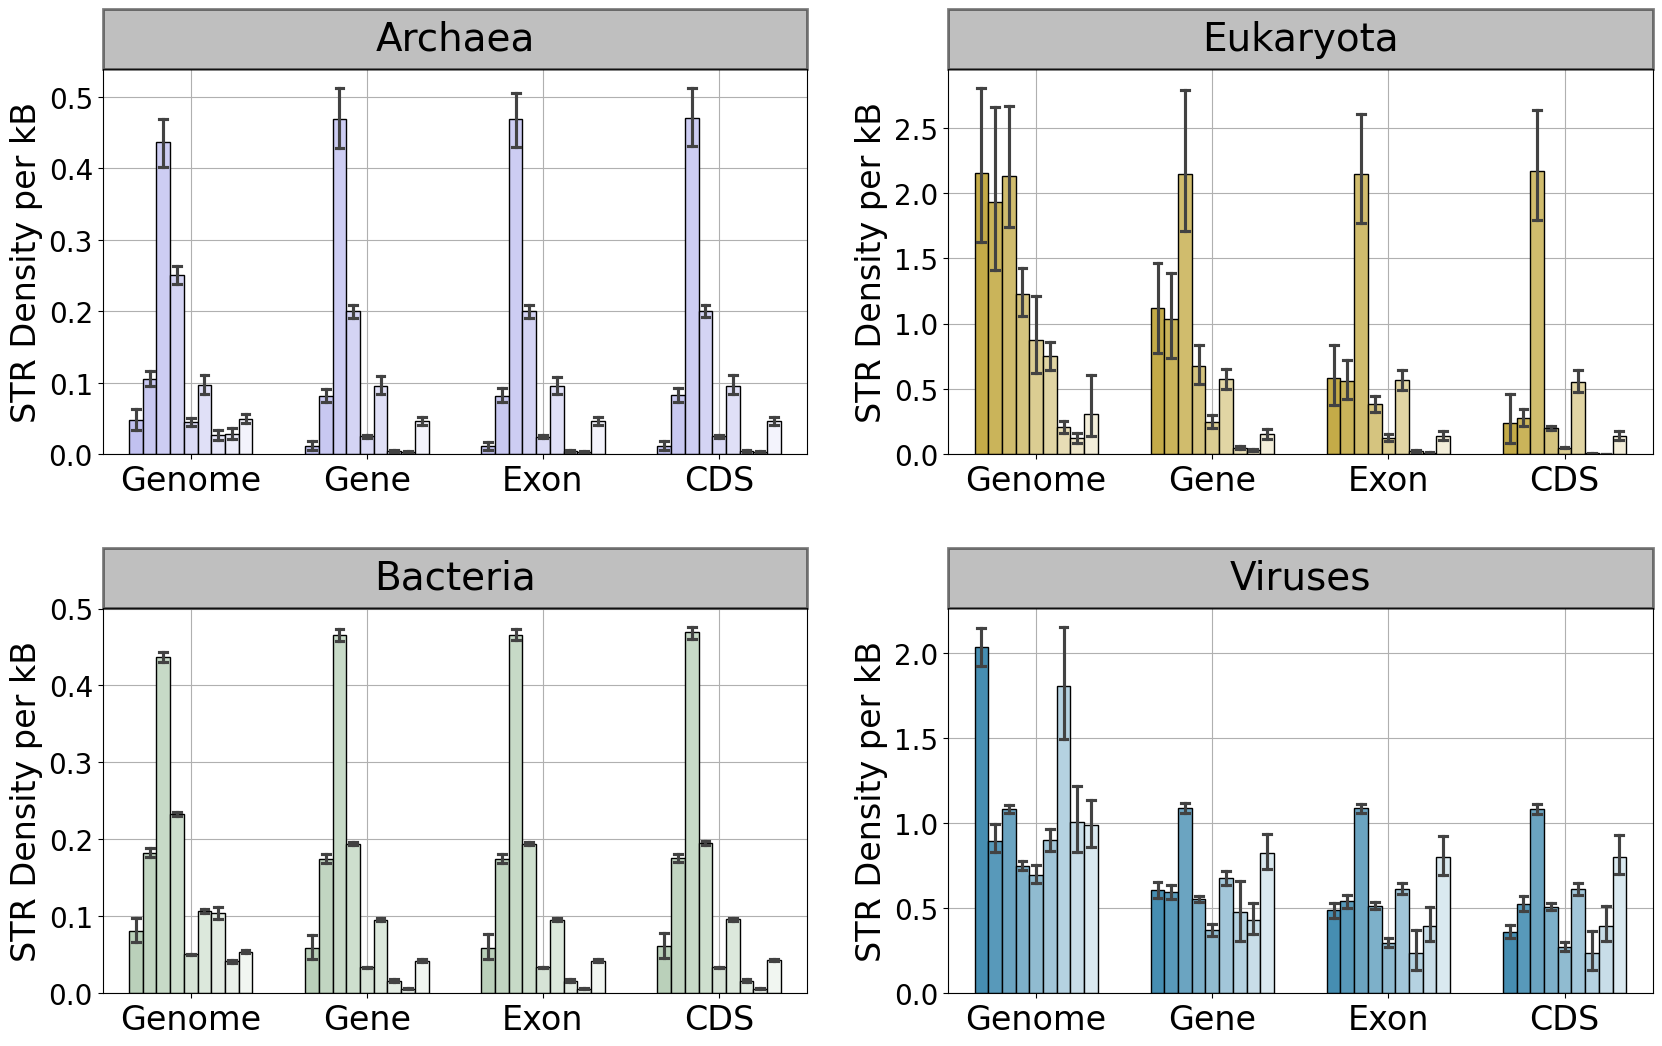

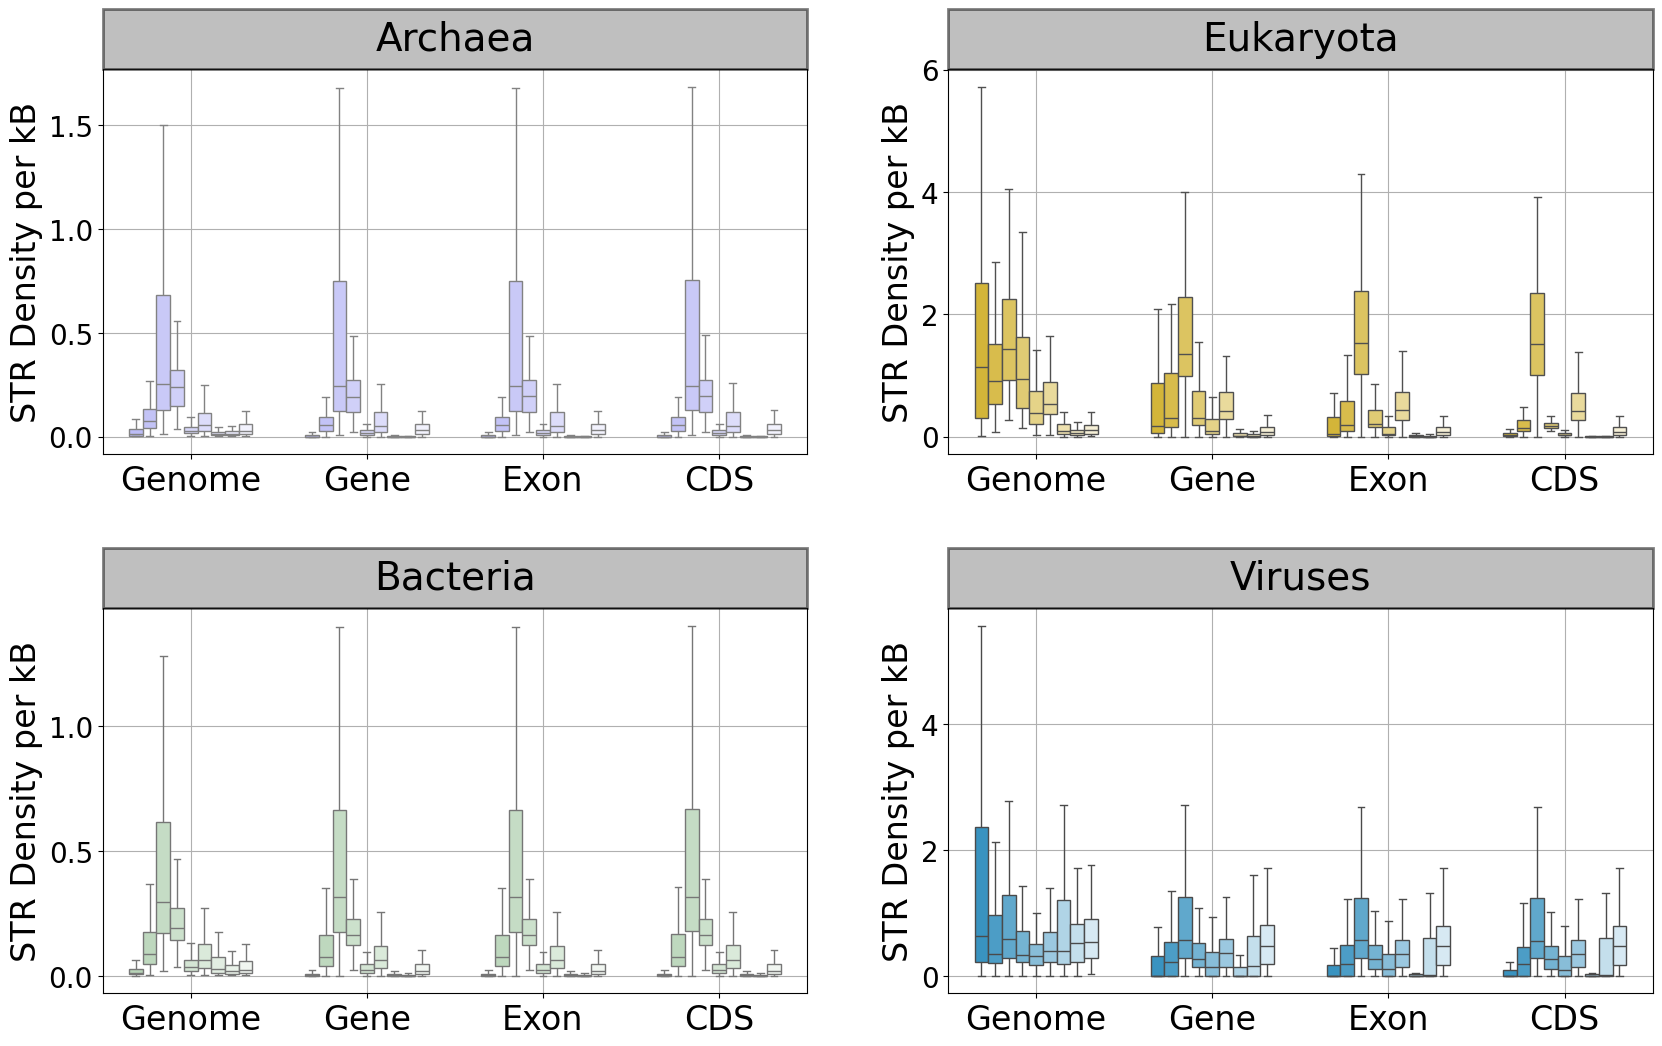

In [253]:
pattern = "STR"
partition_col = "sru"
fig = plot_domain_level_coverage(coverage_STR_df_sru_reduced, partition_col=partition_col, pattern=pattern, save_as=True);
fig = plot_domain_level_coverage_boxplot(coverage_STR_df_sru_reduced, partition_col=partition_col, hue_order=list(range(1, 10)), pattern=pattern, save_as=True);

In [267]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_rgba
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

def blend_with_white(hex_color, alpha):
    rgb = mcolors.to_rgb(hex_color)
    blended = [1 - alpha + c * alpha for c in rgb]  # blend toward white
    return mcolors.to_hex(blended)
    
def plot_domain_level_coverage_boxplot(coverage_df_partition: pd.DataFrame,
                               partition_col: str, 
                               pattern: str,
                               figsize=(20, 12), 
                               hspace=0.4, 
                               alpha=1.0, 
                               wspace=0.2, 
                               capsize=0.4,
                               saturation=0.6,
                               edgecolor='black',
                               linewidth=1.0,
                               width=0.7,
                               palette_=None,
                               rect_height=0.05,
                               major_xtick_font_size=24,
                               xlabel_font_size=24,
                               ylabel_font_size=24,
                               cast_to_int: bool = True,
                               title_font_size=28,
                               facecolor='gray',
                               evaluate_significance: bool = False,
                               comparisons_correction: str = "Bonferroni",
                                fontsize: int = 18,
                               save_as: bool = True,
                               hue_order=list(range(1, 10))):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=figsize)
    fig.subplots_adjust(hspace=hspace, wspace=wspace)
    axes = axes.flatten()
    domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
    order = ["Genome", "Gene", "Exon", "CDS"]
    hue_order = list(hue_order)
    total_hues = len(hue_order)
    domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#b2d8b2',
                'Viruses': '#229ad6',
    }
    if cast_to_int:
        coverage_df_partition.loc[:, partition_col] = coverage_df_partition[partition_col].astype(int)
    for i, domain in enumerate(domains):
        ax = axes[i]
        # palette_ = {i+1: c for i, c in enumerate(palette[domain])}
        if palette_ is None:
            base_hex = domain_colors[domain]
            alphas = [1 - i / (total_hues+1) for i in range(total_hues)]  # from 1.0 to 0.0
            hex_fade = [blend_with_white(base_hex, alpha) for alpha in alphas]
            palette_ = {i: c for i, c in zip(hue_order, hex_fade)}
            print(palette_)
        temp_df = coverage_df_partition.query(f"domain == '{domain}'")
        sns.boxplot(data=temp_df, 
                x="compartment", 
                y="coverage", 
                hue=partition_col, 
                palette=palette_, 
                order=order,
                hue_order=hue_order,    
                ax=ax, 
                showfliers=False,
                width=width, 
                dodge=True)
        palette_ = None
        ax.grid()
        ax.set_axisbelow(True)
        ax.set_ylabel(f"{pattern} Density per kB")
        ax.set_xlabel("")
        ax.yaxis.label.set_size(xlabel_font_size)
        ax.xaxis.label.set_size(ylabel_font_size)
        ax.tick_params(axis="both", labelsize=20)
        ax.tick_params(axis="x", labelsize=major_xtick_font_size)
        ax.legend(handles=[], frameon=False)
        if evaluate_significance:
                compartments = temp_df["compartment"].unique()
                partitions = temp_df[partition_col].unique()
                pairs=[tuple((q, col) for col in partitions) for q in compartments]
                annotator = Annotator(ax, 
                                      pairs, 
                                      data=temp_df, 
                                      x="compartment", 
                                      hue=partition_col,
                                      y="coverage", 
                                      # order=order
                                     )
                annotator.configure(test='t-test_ind',  
                                    comparisons_correction=comparisons_correction,
                                    text_format='star',
                                    fontsize=fontsize,
                                    loc='inside')
                annotator.apply_and_annotate()
              
        bbox = ax.get_position()
        rect_height = rect_height
        rect_bottom = bbox.y1
        rect_left = bbox.x0
        rect_width = bbox.x1 - bbox.x0
        fig.patches.append(Rectangle((rect_left, rect_bottom), rect_width, rect_height,
                                     edgecolor="black",
                                     linewidth=2.0,
                                     transform=fig.transFigure, 
                                     facecolor=facecolor, 
                                     alpha=0.5))
        
        fig.text(rect_left + rect_width / 2, 
                 rect_bottom + rect_height / 2, 
                 s=domain,
                 ha='center', 
                 va='center', 
                 color='black', 
                 fontsize=28
                )
        
    if save_as:
        target = Path(f"/storage/group/izg5139/default/nicole/STR_RTR/{pattern}_figures/TSS_TES").resolve()
        target.mkdir(exist_ok=True, parents=True)
        fig.savefig(f"{target}/coverage_domain_level_compartments_{pattern}_{partition_col}_boxplot.pdf", bbox_inches="tight")
    return fig


pattern = "STR"
partition_col = "sru"
# fig = plot_domain_level_coverage(coverage_df_sru, partition_col=partition_col, pattern=pattern, save_as=True);

In [207]:
color_templates

{'template': {'Viruses': '#229ad6',
  'Bacteria': '#0fbf2d',
  'Eukaryota': '#edc41f',
  'Archaea': '#b2b2ff'},
 'non-template': {'Viruses': '#66C28B',
  'Bacteria': '#FC8D62',
  'Eukaryota': '#6CA5C4',
  'Archaea': '#9A3BD1'}}

In [37]:
phylum_to_domain = dict(zip(tree_of_life["phylum"], tree_of_life["domain"]))
len(phylum_to_domain)

129

In [38]:
coverage_STR_df.shape

(440385, 23)

In [39]:
coverage_STR_df_reduced.shape

(161218, 6)

In [40]:
import polars as pl
import numpy as np

# STR
coverage_STR_df_phylum = coverage_STR_df_reduced.assign(coverage_log=lambda ds: ds["coverage"].apply(lambda ds: np.log10(ds+1)))\
                                    .dropna(subset=["phylum"]).groupby(["compartment", "phylum"], as_index=False)\
                                    .agg(log_STR_density=("coverage_log", "mean"))\
                                    .pivot(columns="compartment", index="phylum", values="log_STR_density")
coverage_STR_df_phylum = pl.from_pandas(coverage_STR_df_phylum.reset_index())

In [78]:
target.joinpath(f"STR_clustermap_compartments_phylum_level.pdf")

PosixPath('/storage/group/izg5139/default/nicole/STR_RTR/STR_figures/TSS_TES/STR_clustermap_compartments_phylum_level.pdf')

/tmp/ipykernel_3368271/1085065831.py:22: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("phylum").map_elements(lambda x: ...)
with this one instead:
  + pl.col("phylum").replace_strict(phylum_to_domain)

  domains = list(coverage_df_phylum.with_columns(pl.col("phylum").map_elements(lambda x: phylum_to_domain[x], return_dtype=str).alias("domain"))["domain"])


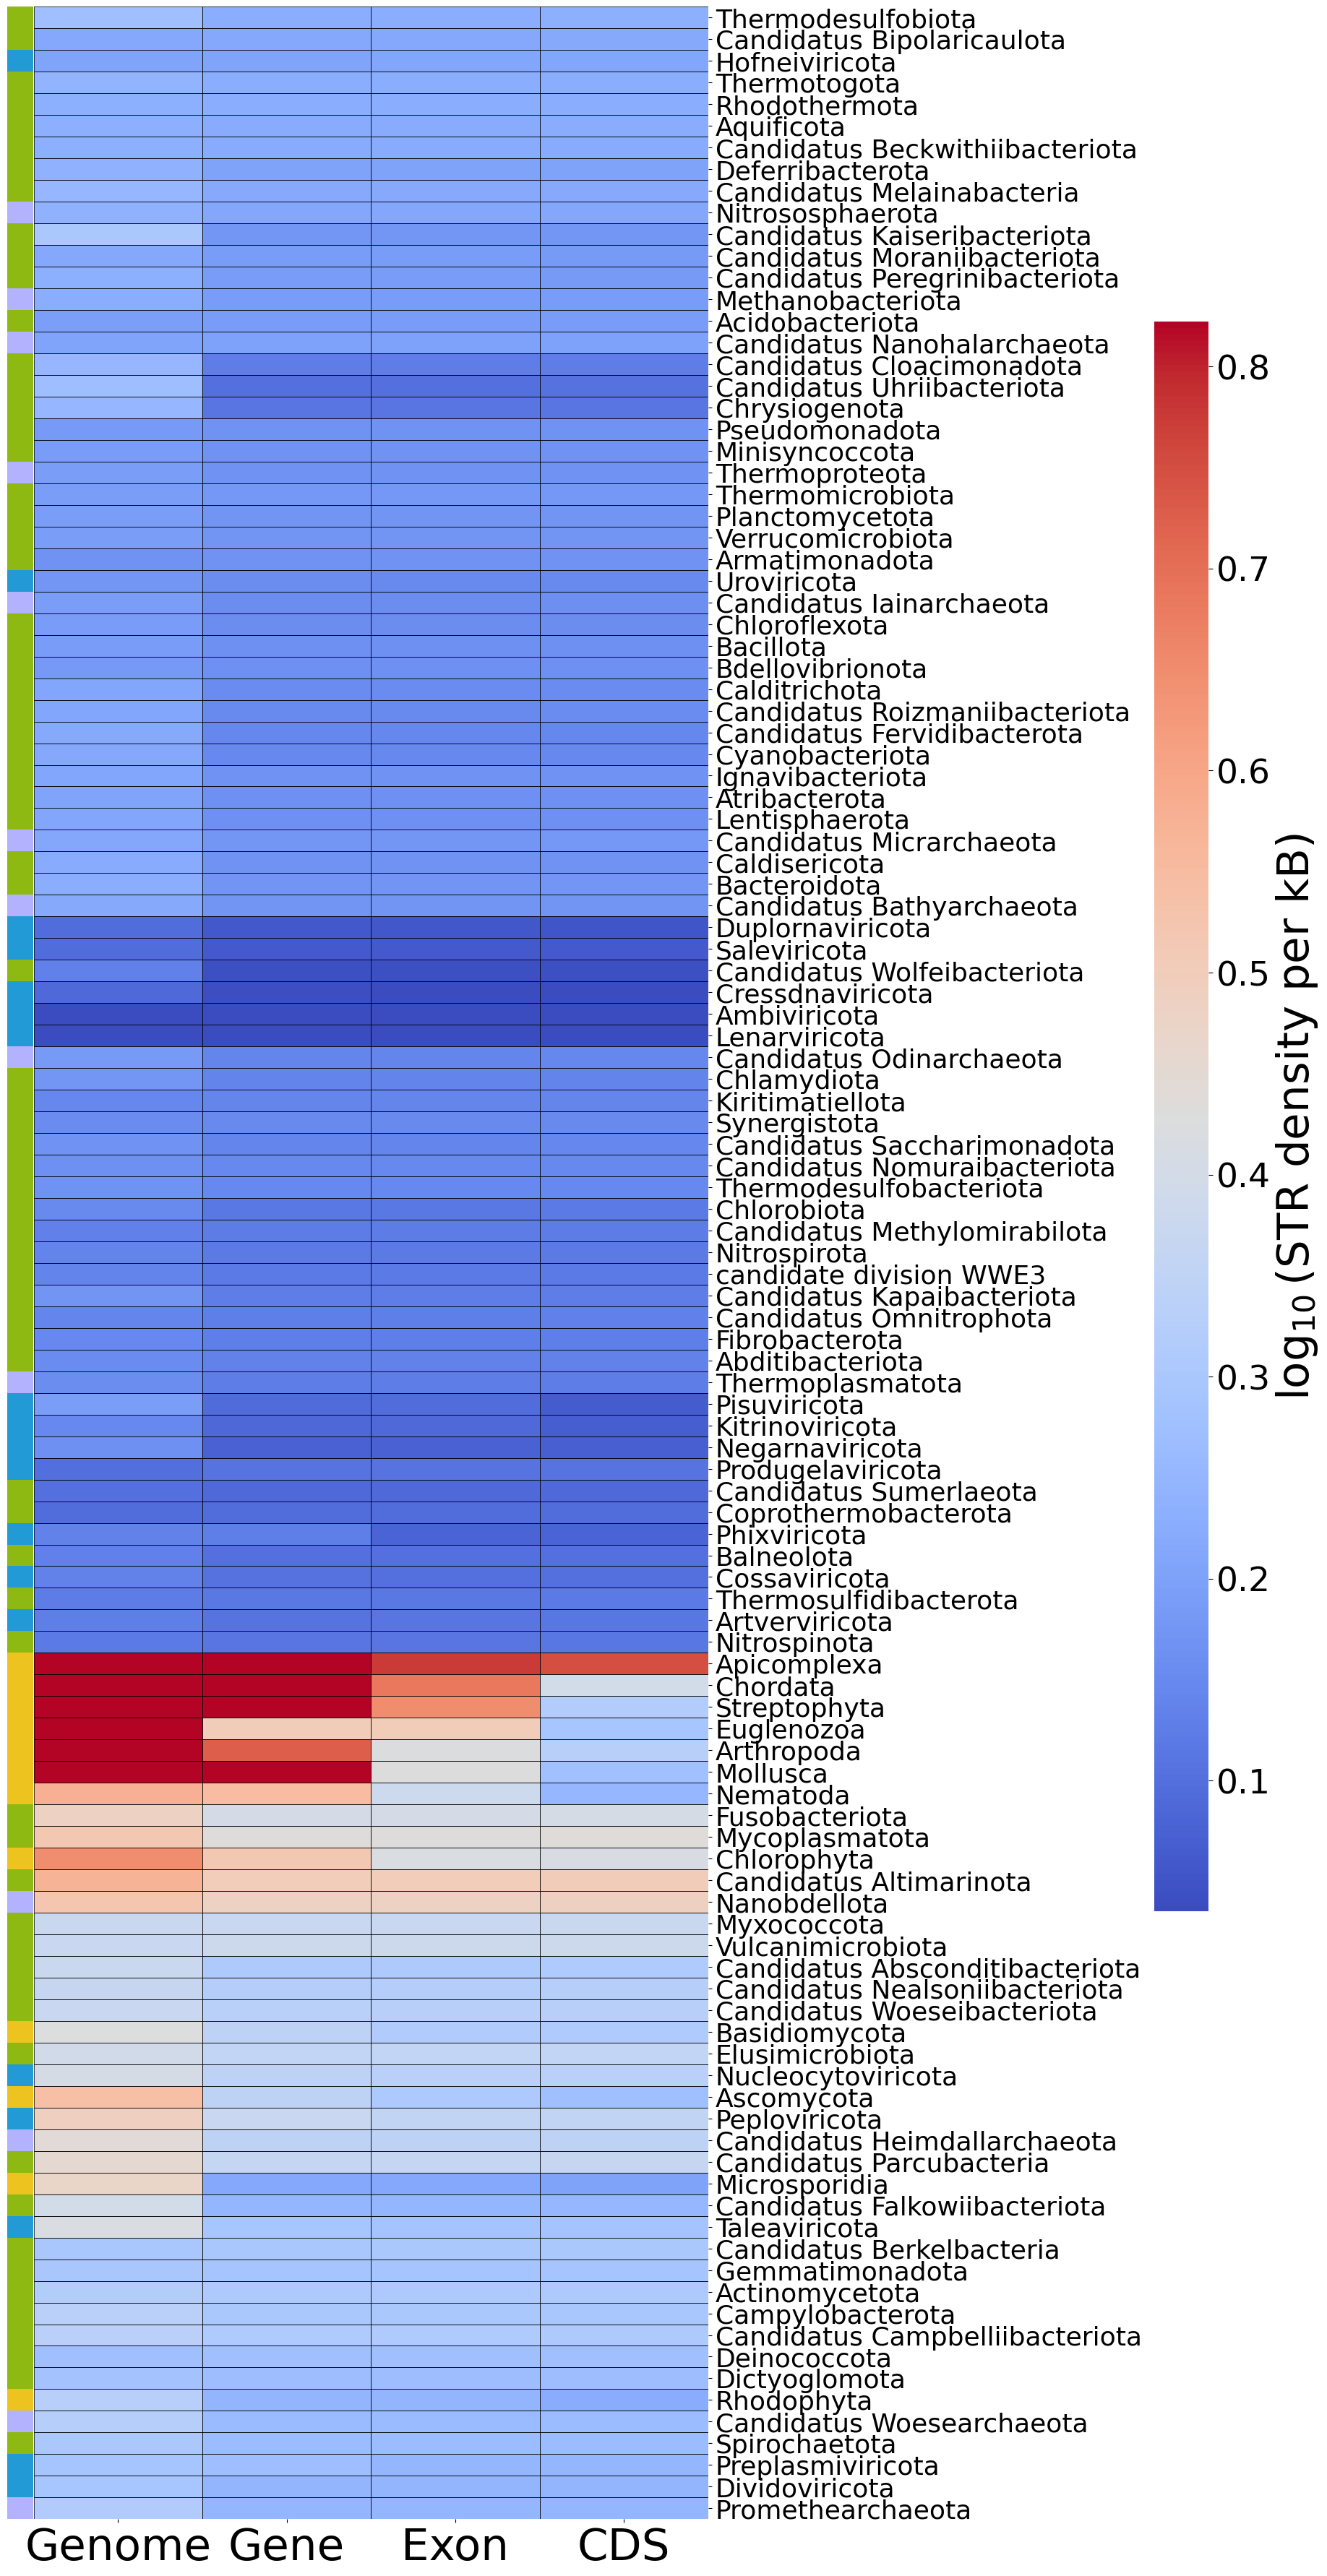

In [246]:
kws = dict(cbar_kws=dict(location="top", shrink=0.2))
figsize=(15, 44)
kingdom_color_palette = {
                'Viruses': '#229ad6',
                "Bacteria": "#0fbf2d",
                "Archaea": "#b2b2ff",
                "Fungi": "#4d325e",
                "Plantae": "#b50996",
                "Eubacteria": "#0fbf2d",
                "Metazoa": "#9bba2d",
                "Protista": "#c78f5b",
                "Archaeabacteria": "#7b7bed",
                } 
domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#b2d8b2',
                'Viruses': '#229ad6',
}
domain_colors.update({"Bacteria": "#8eb812"})
kingdom_color_palette.update({"Bacteria": "#8eb812"})
domains = list(coverage_df_phylum.with_columns(pl.col("phylum").map_elements(lambda x: phylum_to_domain[x], return_dtype=str).alias("domain"))["domain"])
row_colors = [domain_colors[domain] for domain in domains]
order = ["Genome", "Gene", "Exon", "CDS"]

cg = sns.clustermap(
                  coverage_MR_df_phylum.to_pandas().set_index("phylum")[order],
                   row_colors=[row_colors], # kingdom_colors],
                   row_cluster=True, 
                   col_cluster=False,
                    method="ward",
                   #  vmax=1.0,
                    cmap="coolwarm",
                   figsize=figsize,
                   robust=True,
                   yticklabels=True, 
                   xticklabels=True,
                   cbar_kws={"shrink": 0.1, 
                             "orientation": "vertical"}
                   )
ax = cg.ax_heatmap
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)
ax = cg.ax_heatmap
ax.set_ylabel("")
t = ax.xaxis.get_majorticklocs()
ax.xaxis.label.set_size(22)
ax.yaxis.label.set_size(22)
ax.tick_params(axis="both", 
               which="major", 
               labelsize=26,
               rotation=0
              )
ax.tick_params(axis="x", 
               which="major", 
               labelsize=44,
               rotation=0
              )


x0, _y0, _w, _h = cg.cbar_pos
cg.ax_cbar.set_position([1.23, 0.2, 0.05, 0.5])
cg.ax_cbar.tick_params(axis='both', length=4, labelsize=34)


cg.cax.set_ylabel(r'$\log_{10}(\mathrm{STR\ density\ per\ kB})$', size=44)
for spine in cg.ax_cbar.spines:
    cg.ax_cbar.spines[spine].set_color('black')
    # cg.ax_cbar.spines[spine].set_linewidth(2)

ax.set_xlabel("", size=36)
import matplotlib.patches as patches
data = coverage_MR_df_phylum.to_pandas().loc[cg.dendrogram_row.reordered_ind]
n_rows, n_cols = data.shape
for i in range(n_rows):
    for j in range(n_cols):
        rect = patches.Rectangle((j, i), 1, 1, linewidth=0.5, edgecolor='black', facecolor='none')
        ax.add_patch(rect)

fig = plt.gcf()
target = Path("/storage/group/izg5139/default/nicole/STR_RTR/STR_figures/TSS_TES").resolve()
target.mkdir(exist_ok=True)
fig.savefig(target.joinpath(f"MR_clustermap_compartments_phylum_level.pdf"), bbox_inches='tight', dpi=600)
plt.show()

## Density

In [250]:
tss = pd.read_table("/storage/group/izg5139/default/nicole/STR_RTR/coverage/enrichment_out/mode_density/enrichment_gene_density.TSS.txt")
tes = pd.read_table("/storage/group/izg5139/default/nicole/STR_RTR/coverage/enrichment_out/mode_density/enrichment_gene_density.TES.txt")
tss

,-500,-499,-498,-497,-496,-495,-494,-493,-492,-491,...,matched_targets_heteropolarity,matched_targets_homopolarity,target_perc,total_queries,matched_queries,query_perc,site,biotype,sru,#assembly_accession
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,50.00,1715,1,0.06,TSS,protein_coding,1,GCF_000006785.2
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,50.00,1715,4,0.23,TSS,protein_coding,2,GCF_000006785.2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,88.46,1715,28,1.63,TSS,protein_coding,3,GCF_000006785.2
3,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,80.00,1715,20,1.17,TSS,protein_coding,4,GCF_000006785.2
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,66.67,1715,2,0.12,TSS,protein_coding,5,GCF_000006785.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2314775,32.0,29.0,29.0,29.0,28.0,25.0,25.0,26.0,26.0,24.0,...,NaN,NaN,2.10,41815,1151,2.75,TSS,.,6,GCF_028858775.2
2314776,9.0,9.0,8.0,7.0,7.0,7.0,6.0,6.0,4.0,4.0,...,NaN,NaN,1.93,41815,329,0.79,TSS,.,7,GCF_028858775.2
2314777,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,1.97,41815,116,0.28,TSS,.,8,GCF_028858775.2
2314778,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,2.90,41815,68,0.16,TSS,.,9,GCF_028858775.2


In [294]:
tss["#assembly_accession"].nunique(), tes["#assembly_accession"].nunique()

(88734, 88734)

In [281]:
tss_tree_of_life = tss.query("biotype == '.'").merge(
                            tree_of_life[["#assembly_accession", "species_taxid", "organism_name", "phylum", "kingdom", "domain"]],
                            on="#assembly_accession"
)
tes_tree_of_life = tes.query("biotype == '.'").merge(
                            tree_of_life[["#assembly_accession", "species_taxid", "organism_name", "phylum", "kingdom", "domain"]],
                            on="#assembly_accession"
)

In [339]:
tss_tree = tss_tree_of_life.query("domain == 'Eukaryota'")
tes_tree = tss_tree_of_life.query("domain == 'Eukaryota'")

tss_tree

,-500,-499,-498,-497,-496,-495,-494,-493,-492,-491,...,query_perc,site,biotype,sru,#assembly_accession,species_taxid,organism_name,phylum,kingdom,domain
220,26.0,26.0,27.0,27.0,28.0,33.0,33.0,38.0,39.0,35.0,...,19.34,TSS,.,1,GCF_000226095.1,78579,Thermothelomyces thermophilus ATCC 42464,Ascomycota,Fungi,Eukaryota
221,10.0,11.0,12.0,11.0,9.0,9.0,9.0,9.0,10.0,10.0,...,9.84,TSS,.,2,GCF_000226095.1,78579,Thermothelomyces thermophilus ATCC 42464,Ascomycota,Fungi,Eukaryota
222,14.0,13.0,13.0,15.0,14.0,15.0,16.0,15.0,16.0,16.0,...,15.53,TSS,.,3,GCF_000226095.1,78579,Thermothelomyces thermophilus ATCC 42464,Ascomycota,Fungi,Eukaryota
223,22.0,22.0,25.0,23.0,22.0,25.0,26.0,24.0,24.0,27.0,...,12.84,TSS,.,4,GCF_000226095.1,78579,Thermothelomyces thermophilus ATCC 42464,Ascomycota,Fungi,Eukaryota
224,6.0,6.0,4.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0,...,2.83,TSS,.,5,GCF_000226095.1,78579,Thermothelomyces thermophilus ATCC 42464,Ascomycota,Fungi,Eukaryota
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887335,32.0,29.0,29.0,29.0,28.0,25.0,25.0,26.0,26.0,24.0,...,2.75,TSS,.,6,GCF_028858775.2,9598,Pan troglodytes,Chordata,Metazoa,Eukaryota
887336,9.0,9.0,8.0,7.0,7.0,7.0,6.0,6.0,4.0,4.0,...,0.79,TSS,.,7,GCF_028858775.2,9598,Pan troglodytes,Chordata,Metazoa,Eukaryota
887337,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,...,0.28,TSS,.,8,GCF_028858775.2,9598,Pan troglodytes,Chordata,Metazoa,Eukaryota
887338,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.16,TSS,.,9,GCF_028858775.2,9598,Pan troglodytes,Chordata,Metazoa,Eukaryota


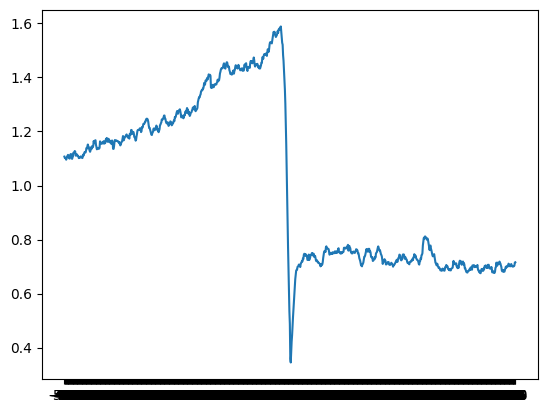

In [342]:
window_size = 500
t = tss_tree.reset_index(drop=True)\
                        .groupby("species_taxid")\
                        .agg({str(i): "sum" for i in range(-window_size, window_size+1)})[xrange]\
                        .reset_index(drop=True)
t = t.apply(lambda row: row / row.mean(), axis=1)
t = t.mean()
plt.plot(xrange, t.values)

In [ ]:
## from tqdm import tqdm
from collections import defaultdict
import random
import numpy as np

def gini_coefficient(values):
    if not values:
        return 0.0
    sorted_vals = sorted(values)
    total_tokens = sum(sorted_vals)
    population = len(sorted_vals)
    cumulative = 0
    gini_index = 0.0
    total = 0
    for i, val in enumerate(sorted_vals, start=1):
        cumulative += val
        gini_index += i / population - cumulative / total_tokens
        total += i / population
    return gini_index / (total-1)

partition_col = "sru"
partition_col = None

if partition_col:
    tss_tree_grped = tss_tree.groupby(["species_taxid", partition_col], as_index=False)\
                            .agg({str(i): "sum" for i in range(-window_size, window_size+1)} | {"domain": "first", "phylum": "first"})

    tes_tree_grped = tes_tree.groupby(["species_taxid", partition_col], as_index=False)\
                                .agg({str(i): "sum" for i in range(-window_size, window_size+1)} | {"domain": "first", "phylum": "first"})
else:
    tss_tree_grped = tss_tree.groupby(["species_taxid"], as_index=False)\
                            .agg({str(i): "sum" for i in range(-window_size, window_size+1)} | {"domain": "first", "phylum": "first"})

    tes_tree_grped = tes_tree.groupby(["species_taxid"], as_index=False)\
                                .agg({str(i): "sum" for i in range(-window_size, window_size+1)} | {"domain": "first", "phylum": "first"})

use_bootstrap = True
tss_gini_pos = defaultdict(list)
N = 1_000
alpha = 0.05

phylum = "Chordata"
tss_temp_df = tss_tree_grped.query(f"phylum == '{phylum}'")
tes_temp_df = tes_tree_grped.query(f"phylum == '{phylum}'")
for col in tqdm(xrange, leave=True, position=0):
    tss_gini_pos["pos"].append(col)
    tss_list = tss_temp_df[col].tolist()
    tes_list = tes_temp_df[col].tolist()
    if sum(tss_list) == 0:
        tss_gini_pos["tss_gini"].append(0)
    else:
        tss_gini_pos["tss_gini"].append(gini_coefficient(tss_list))
    if sum(tes_list) == 0:
        tss_gini_pos["tes_gini"].append(0)
    else:
        tss_gini_pos["tes_gini"].append(gini_coefficient(tes_list))
    #
    if use_bootstrap:
        bootstrap_tss = []
        bootstrap_tes = []
        for _ in range(N):
            tss_resampled = [random.choice(tss_list) for _ in range(len(tss_list))]
            tes_resampled = [random.choice(tes_list) for _ in range(len(tes_list))]
            if sum(tes_resampled) == 0:
                gini_coef_tes = 0
            else:
                gini_coef_tes = gini_coefficient(tes_resampled)y
                
            if sum(tss_resampled) == 0:
                gini_coef_tss = 0
            else:
                gini_coef_tss = gini_coefficient(tss_resampled)
            bootstrap_tss.append(gini_coef_tss)
            bootstrap_tes.append(gini_coef_tes)

        tss_lower_ci, tss_upper_ci = np.quantile(bootstrap_tss, [alpha/2, 1-alpha/2])
        tes_lower_ci, tes_upper_ci = np.quantile(bootstrap_tes, [alpha/2, 1-alpha/2])
        tss_gini_pos["tss_gini_lower_ci"].append(tss_lower_ci)
        tss_gini_pos["tss_gini_upper_ci"].append(tss_upper_ci)
        tss_gini_pos["tes_gini_lower_ci"].append(tes_lower_ci)
        tss_gini_pos["tes_gini_upper_ci"].append(tes_upper_ci)

tss_gini_pos = pd.DataFrame(tss_gini_pos)
tss_gini_pos

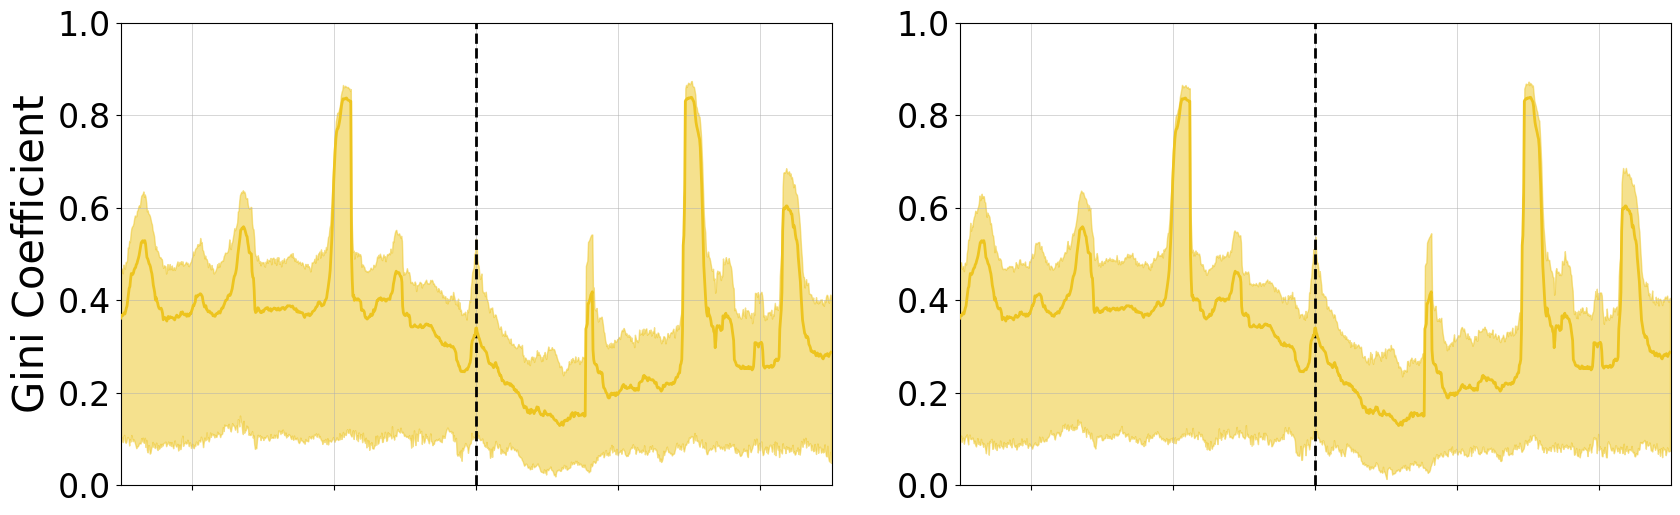

In [323]:
window_size = 500
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
plt.subplots_adjust(wspace=0.18, hspace=0.12)
domain = "Eukaryota"
xaxis = range(-window_size, window_size+1)
ax[0].plot(xaxis, 
        tss_gini_pos["tss_gini"], 
        color=color_templates['template'][domain], 
        lw=linewidth, 
        zorder=3)
ax[0].fill_between(xaxis, 
                    y1=tss_gini_pos["tss_gini_lower_ci"], 
                    y2=tss_gini_pos["tss_gini_upper_ci"],
                    color=color_templates['template'][domain], 
                        alpha=0.5
                )
# TES
ax[1].plot(xaxis, 
        tss_gini_pos["tes_gini"], 
        color=color_templates['template'][domain], 
        lw=linewidth, 
        zorder=3)
ax[1].fill_between(xaxis, 
                    y1=tss_gini_pos["tes_gini_lower_ci"], 
                    y2=tss_gini_pos["tes_gini_upper_ci"],
                    color=color_templates['template'][domain], 
                        alpha=0.5
                )
def _modify_axis(ax, transcription_site):
    # xticks = ax.get_xticks()
    # ax.set_xticks(range(0, len(xticks), 100))
    if transcription_site == "start":
        # ax.set_ylabel("")
        ax.set_ylabel("Gini Coefficient")
    else:
        ax.set_ylabel("")
    ax.set_ylim(ymin=0, ymax=1)
    ax.set_xlim(-window_size, window_size+1)
    ax.yaxis.label.set_size(30)
    ax.xaxis.label.set_size(21)
    ax.tick_params(axis="both", which="major", labelsize=24)
    if idx != 3:
        ax.set_xticklabels([])
    ax.grid(True, which='both', axis='x') 
    ax.grid(axis="both", lw=0.4, alpha=0.6, zorder=0)
    ax.grid(axis="both", lw=0.6, alpha=0.6, zorder=0)
    ax.axvline(0, linestyle='--', color='black', lw=2.0)
    return ax

ax[0] = _modify_axis(ax[0], transcription_site="start")
ax[1] = _modify_axis(ax[1], transcription_site="end")

In [282]:
tss_tree_of_life[tss_tree_of_life["organism_name"].str.startswith("Cara")].head()

,-500,-499,-498,-497,-496,-495,-494,-493,-492,-491,...,query_perc,site,biotype,sru,#assembly_accession,species_taxid,organism_name,phylum,kingdom,domain
164150,433.0,439.0,423.0,415.0,425.0,461.0,489.0,528.0,552.0,644.0,...,44.96,TSS,.,1,GCF_023724105.1,101364,Carassius gibelio,Chordata,Metazoa,Eukaryota
164151,1043.0,1068.0,1084.0,1096.0,1092.0,1092.0,1109.0,1113.0,1103.0,1123.0,...,19.28,TSS,.,2,GCF_023724105.1,101364,Carassius gibelio,Chordata,Metazoa,Eukaryota
164152,222.0,225.0,221.0,227.0,219.0,226.0,227.0,226.0,225.0,212.0,...,9.25,TSS,.,3,GCF_023724105.1,101364,Carassius gibelio,Chordata,Metazoa,Eukaryota
164153,405.0,405.0,393.0,389.0,385.0,383.0,380.0,387.0,393.0,383.0,...,13.28,TSS,.,4,GCF_023724105.1,101364,Carassius gibelio,Chordata,Metazoa,Eukaryota
164154,78.0,80.0,81.0,80.0,76.0,78.0,82.0,77.0,81.0,79.0,...,3.48,TSS,.,5,GCF_023724105.1,101364,Carassius gibelio,Chordata,Metazoa,Eukaryota


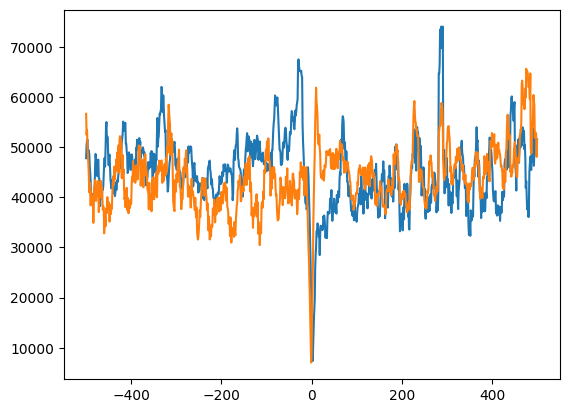

In [283]:
plt.plot(range(-window_size, window_size+1), tss_tree_of_life.query("sru == '2'")[xrange].sum())
plt.plot(range(-window_size, window_size+1), tes_tree_of_life.query("sru == '2'")[xrange].sum())

In [284]:
tss_gibelio = tss_tree_of_life.query("organism_name == 'Carassius gibelio' & sru == '1'")[xrange]
tss_gibelio.T / tss_gibelio.mean(axis=1)

,164150
-500,0.324172
-499,0.328664
-498,0.316685
-497,0.310696
-496,0.318183
...,...
496,0.200642
497,0.201391
498,0.223851
499,0.234332


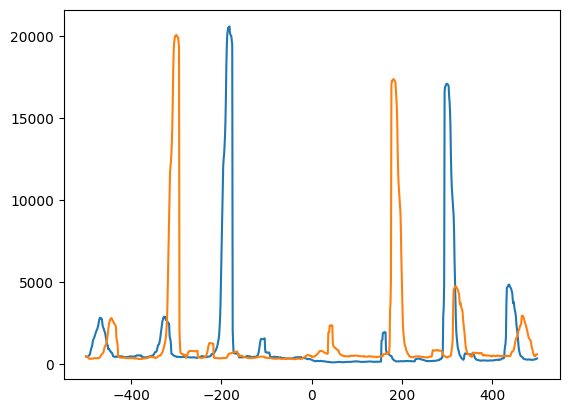

In [285]:
tss_gibelio = tss_tree_of_life.query("organism_name == 'Carassius gibelio' & sru == '1'")[xrange].T
tes_gibelio = tes_tree_of_life.query("organism_name == 'Carassius gibelio' & sru == '1'")[xrange].T

plt.plot(range(-window_size, window_size+1), tss_gibelio)
plt.plot(range(-window_size, window_size+1), tes_gibelio)

In [286]:
xrange = list(map(str, range(-window_size, window_size+1)))

tss_gibelio = tss_tree_of_life.query("organism_name == 'Carassius gibelio' & sru == '1'")[xrange]
tss_gibelio = tss_gibelio.T / tss_gibelio.mean(axis=1)
tes_gibelio = tes_tree_of_life.query("organism_name == 'Carassius gibelio' & sru == '1'")[xrange]
tes_gibelio = tes_gibelio.T / tes_gibelio.mean(axis=1)
tss_gibelio

,164150
-500,0.324172
-499,0.328664
-498,0.316685
-497,0.310696
-496,0.318183
...,...
496,0.200642
497,0.201391
498,0.223851
499,0.234332


In [287]:
tss_chordata_no_gibelio = tss_tree_of_life.query("organism_name != 'Carassius gibelio' & sru == '1' & phylum == 'Chordata'")\
                                .groupby(["species_taxid"], as_index=False)\
                                .agg({str(i): "sum" for i in range(-window_size, window_size+1)})

tes_chordata_no_gibelio = tes_tree_of_life.query("organism_name != 'Carassius gibelio' & sru == '1' & phylum == 'Chordata'")\
                                          .groupby(["species_taxid"], as_index=False)\
                                          .agg({str(i): "sum" for i in range(-window_size, window_size+1)})

In [288]:
from tqdm import tqdm

alpha = 0.95
N = 1000
window_size = 500
tss_bootstrap_data = []
tes_bootstrap_data = []
xrange = list(map(str, range(-window_size, window_size+1)))
for _ in tqdm(range(N)):
    tss_data = tss_chordata_no_gibelio.sample(frac=1.0, replace=True)[xrange].sum()
    tss_data = tss_data / tss_data.mean()
    tss_bootstrap_data.append(tss_data.to_frame().T)

    tes_data = tes_chordata_no_gibelio.sample(frac=1.0, replace=True)[xrange].sum()
    tes_data = tes_data / tes_data.mean()
    tes_bootstrap_data.append(tes_data.to_frame().T)
    
tss_bootstrap_data = pd.concat(tss_bootstrap_data, ignore_index=True)
tes_bootstrap_data = pd.concat(tes_bootstrap_data, ignore_index=True)
tss_bootstrap_data

100%|██████████| 1000/1000 [00:05<00:00, 193.38it/s]


,-500,-499,-498,-497,-496,-495,-494,-493,-492,-491,...,491,492,493,494,495,496,497,498,499,500
0,1.370013,1.339694,1.337800,1.355801,1.354854,1.359591,1.364328,1.318851,1.300849,1.298007,...,1.047880,1.030826,1.053565,1.017561,1.056407,1.067776,1.045037,1.028931,1.020404,1.020404
1,1.422719,1.378841,1.384160,1.396126,1.378841,1.386819,1.412082,1.394797,1.377511,1.358896,...,1.143494,1.102275,1.057067,1.009200,1.015848,1.043771,1.003881,1.025156,1.023826,1.009200
2,1.293760,1.284359,1.306686,1.329012,1.321962,1.329012,1.363089,1.346638,1.333713,1.312561,...,1.085771,1.056394,1.064620,1.036418,1.029368,1.048169,1.035243,1.023492,1.034068,1.016442
3,1.236110,1.221253,1.247253,1.279938,1.293309,1.303709,1.348281,1.359424,1.320052,1.296281,...,1.092739,1.074910,1.089025,1.068225,1.060053,1.068967,1.056339,1.071939,1.067482,1.055596
4,1.350206,1.323875,1.337040,1.342160,1.364834,1.378731,1.420423,1.421154,1.367029,1.357520,...,1.096402,1.084700,1.098597,1.048860,1.052517,1.052517,1.037889,1.062757,1.036426,1.026917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.279475,1.237540,1.255512,1.290601,1.304295,1.308574,1.348798,1.358212,1.316276,1.284611,...,1.139974,1.114299,1.080921,1.051823,1.044976,1.061237,1.031283,1.071507,1.062093,1.048400
996,1.262336,1.246118,1.266841,1.298377,1.296575,1.300179,1.322705,1.297476,1.278554,1.265940,...,1.034377,1.015455,1.046991,1.028971,1.050595,1.068616,1.056902,1.031674,1.043387,1.035278
997,1.267439,1.265352,1.283086,1.316467,1.319596,1.326899,1.356107,1.337330,1.324812,1.300820,...,1.080713,1.056720,1.078627,1.059850,1.054634,1.067152,1.057764,1.048375,1.052548,1.041073
998,1.308021,1.282850,1.287190,1.328852,1.341872,1.350552,1.374855,1.367043,1.340136,1.312361,...,1.125749,1.101446,1.093634,1.072803,1.077143,1.088427,1.061520,1.091898,1.077143,1.074539


In [289]:
alpha = 0.05
# TES
tss_bootstrap_data_avg = tss_bootstrap_data.mean()
tss_bootstrap_data_lower_ci = tss_bootstrap_data.quantile(alpha / 2)
tss_bootstrap_data_upper_ci = tss_bootstrap_data.quantile(1-alpha / 2)

# TES
tes_bootstrap_data_avg = tes_bootstrap_data.mean()
tes_bootstrap_data_lower_ci = tes_bootstrap_data.quantile(alpha / 2)
tes_bootstrap_data_upper_ci = tes_bootstrap_data.quantile(1-alpha / 2)

In [290]:
tes_bootstrap_data_avg

-500    0.830012
-499    0.824003
-498    0.811290
-497    0.809994
-496    0.807421
          ...   
496     1.051522
497     1.061769
498     1.076872
499     1.064821
500     1.067421
Length: 1001, dtype: float64

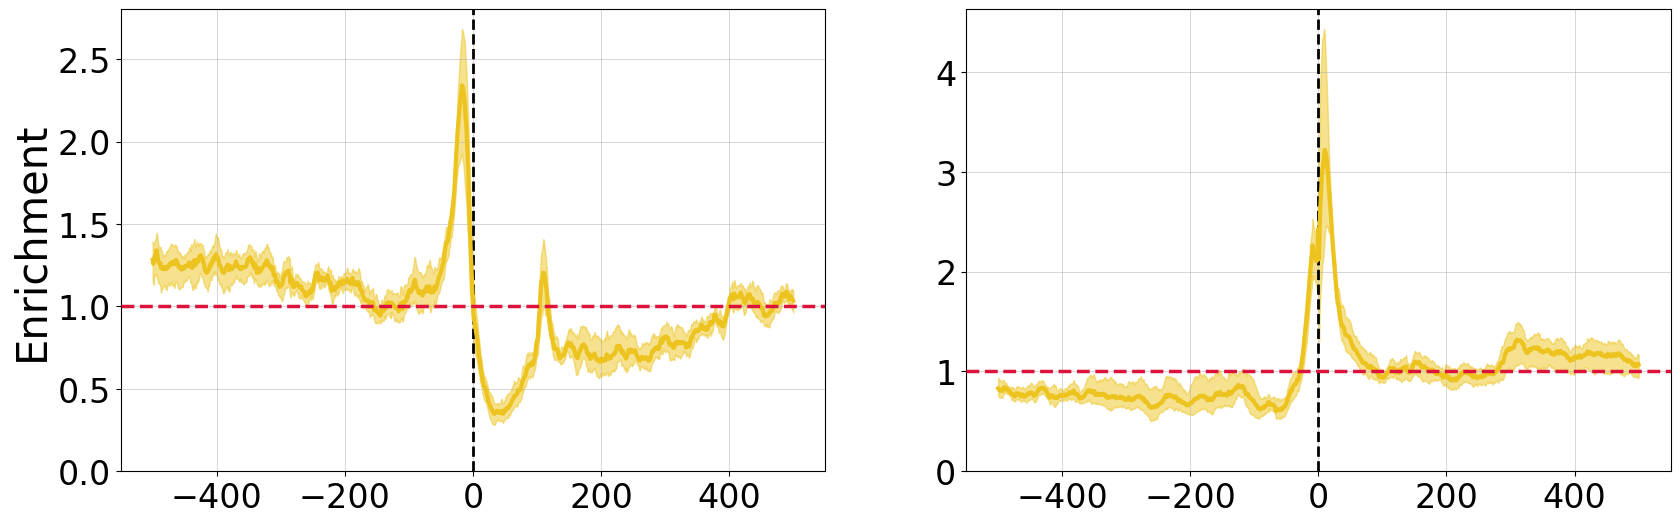

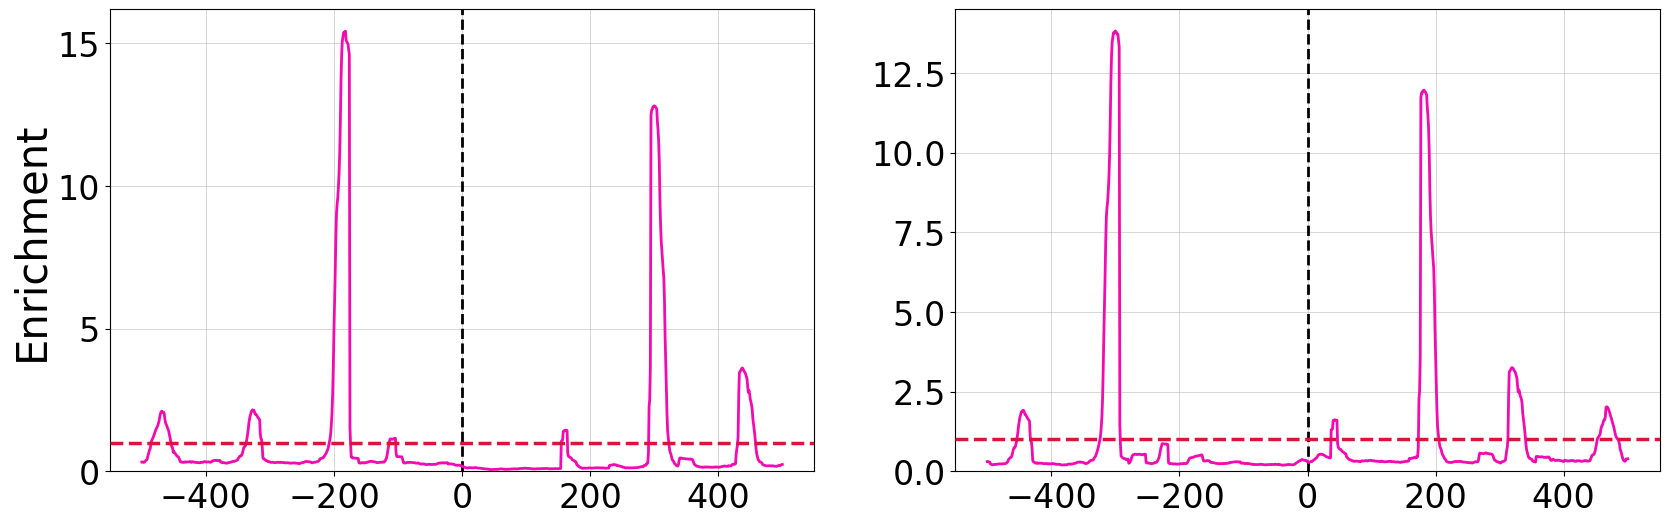

In [291]:
# Chordata TSS-TES
linewidth = 3.0
figsize = (20, 6)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=figsize)
ax = ax.flatten()
xaxis = range(-window_size, window_size+1)
ax[0].plot(xaxis, 
        tss_bootstrap_data_avg, 
        color=color_templates['template']['Eukaryota'], 
        lw=linewidth, 
        zorder=3)
ax[0].fill_between(xaxis, 
                    y1=tss_bootstrap_data_lower_ci, 
                    y2=tss_bootstrap_data_upper_ci,
                    color=color_templates['template']['Eukaryota'], 
                        alpha=0.5
                )
# TES
ax[1].plot(xaxis, 
        tes_bootstrap_data_avg, 
        color=color_templates['template']['Eukaryota'], 
        lw=linewidth, 
        zorder=3)
ax[1].fill_between(xaxis, 
                    y1=tes_bootstrap_data_lower_ci, 
                    y2=tes_bootstrap_data_upper_ci,
                    color=color_templates['template']['Eukaryota'], 
                        alpha=0.5
                )
# ax.legend(handles=[mpatches.Patch(color=color_templates['template'][domain], label='Template'),
#                   mpatches.Patch(color=color_templates['non-template'][domain], label='Non-template')
#                  ], loc=0
#         )

def _modify_axis(ax, transcription_site):
    # xticks = ax.get_xticks()
    # ax.set_xticks(range(0, len(xticks), 100))
    if transcription_site == "start":
        # ax.set_ylabel("")
        ax.set_ylabel("Enrichment")
    else:
        ax.set_ylabel("")

    ax.set_ylim(ymin=0)
    
    ax.yaxis.label.set_size(30)
    ax.xaxis.label.set_size(21)
    ax.tick_params(axis="both", which="major", labelsize=24)
    ax.grid(True, which='both', axis='x') 
    ax.grid(axis="both", lw=0.4, alpha=0.6, zorder=0)
    ax.grid(axis="both", lw=0.6, alpha=0.6, zorder=0)
    ax.axvline(0, linestyle='--', color='black', lw=2.0)
    ax.axhline(1.0, linestyle='--', color='crimson', lw=2.5, zorder=5)
    return ax

ax[0] = _modify_axis(ax[0], transcription_site="start")
ax[1] = _modify_axis(ax[1], transcription_site="end")
target = Path("/storage/group/izg5139/default/nicole/STR_RTR/STR_figures/TSS_TES").resolve()
target.mkdir(exist_ok=True)
fig.savefig(target.joinpath(f"chordata_STR_density_TSS_TES_no_gibelio_mononucleotides.pdf"), bbox_inches='tight', dpi=600)

# Carassius Gibelio
gibelio_color = "#f30bb1"
linewidth = 2.0
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=figsize)
ax = ax.flatten()
xaxis = range(-window_size, window_size+1)
ax[0].plot(xaxis, 
        tss_gibelio, 
        color=gibelio_color, 
        lw=linewidth, 
        zorder=3)
# TES
ax[1].plot(xaxis, 
        tes_gibelio, 
        color=gibelio_color, 
        lw=linewidth, 
        zorder=3)

def _modify_axis(ax, transcription_site):
    # xticks = ax.get_xticks()
    # ax.set_xticks(range(0, len(xticks), 100))
    if transcription_site == "start":
        # ax.set_ylabel("")
        ax.set_ylabel("Enrichment")
    else:
        ax.set_ylabel("")

    ax.set_ylim(ymin=0)
    ax.yaxis.label.set_size(30)
    ax.xaxis.label.set_size(21)
    ax.tick_params(axis="both", which="major", labelsize=24)
    ax.grid(True, which='both', axis='x') 
    ax.grid(axis="both", lw=0.4, alpha=0.6, zorder=0)
    ax.grid(axis="both", lw=0.6, alpha=0.6, zorder=0)
    ax.axvline(0, linestyle='--', color='black', lw=2.0)
    ax.axhline(1.0, linestyle='--', color='crimson', lw=2.5, zorder=5)
    return ax

ax[0] = _modify_axis(ax[0], transcription_site="start")
ax[1] = _modify_axis(ax[1], transcription_site="end")
target = Path("/storage/group/izg5139/default/nicole/STR_RTR/STR_figures/TSS_TES").resolve()
target.mkdir(exist_ok=True)
fig.savefig(target.joinpath(f"carassius_gibelio_STR_density_TSS_TES_mononucleotides.pdf"), bbox_inches='tight', dpi=600)

# TSS & TES Domain Level STR

In [1]:
import pandas as pd
from pathlib import Path

density = Path("/storage/group/izg5139/default/nicole/STR_RTR/coverage/enrichment_out/mode_density/domain_bootstrap").resolve()
df = pd.read_csv(density.joinpath("enrichment_bootstrap_alpha_0.05.TES.density.domain.Archaea.csv"))
df

,domain,statistic,bootstrap_level,biotype,sru,-500,-499,-498,-497,-496,...,491,492,493,494,495,496,497,498,499,500
0,Archaea,average,species_taxid,protein-Coding,1,0.702,0.656,0.626,0.527,0.527,...,0.667,0.651,0.567,0.598,0.598,0.667,0.654,0.654,0.652,0.669
1,Archaea,lowerCI,species_taxid,protein-Coding,1,0.519,0.481,0.459,0.382,0.381,...,0.471,0.438,0.394,0.401,0.425,0.478,0.467,0.456,0.474,0.498
2,Archaea,upperCI,species_taxid,protein-Coding,1,0.916,0.850,0.803,0.691,0.681,...,0.885,0.874,0.756,0.793,0.769,0.867,0.859,0.867,0.847,0.868
3,Archaea,average,family,protein-Coding,1,0.701,0.656,0.627,0.524,0.528,...,0.666,0.653,0.553,0.578,0.587,0.658,0.651,0.649,0.651,0.669
4,Archaea,lowerCI,family,protein-Coding,1,0.465,0.448,0.418,0.358,0.367,...,0.488,0.460,0.286,0.311,0.374,0.451,0.475,0.480,0.497,0.521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,Archaea,lowerCI,species_taxid,.,generic,0.836,0.812,0.815,0.796,0.784,...,0.875,0.858,0.862,0.853,0.854,0.873,0.850,0.837,0.827,0.827
176,Archaea,upperCI,species_taxid,.,generic,0.942,0.913,0.923,0.904,0.891,...,1.032,1.006,0.989,0.955,0.954,0.974,0.950,0.942,0.929,0.921
177,Archaea,average,family,.,generic,0.887,0.860,0.865,0.846,0.836,...,0.946,0.925,0.919,0.902,0.901,0.920,0.897,0.887,0.876,0.874
178,Archaea,lowerCI,family,.,generic,0.790,0.756,0.761,0.732,0.725,...,0.872,0.853,0.844,0.821,0.821,0.840,0.805,0.797,0.793,0.781


In [249]:
!ls /storage/group/izg5139/default/nicole/STR_RTR/coverage/enrichment_out/mode_density/domain_bootstrap

/storage/group/izg5139/default/nicole/STR_RTR/STR_figures/TSS_TES
/storage/group/izg5139/default/nicole/STR_RTR/STR_figures/TSS_TES/STR_TSS_TES_distribution_domains.png


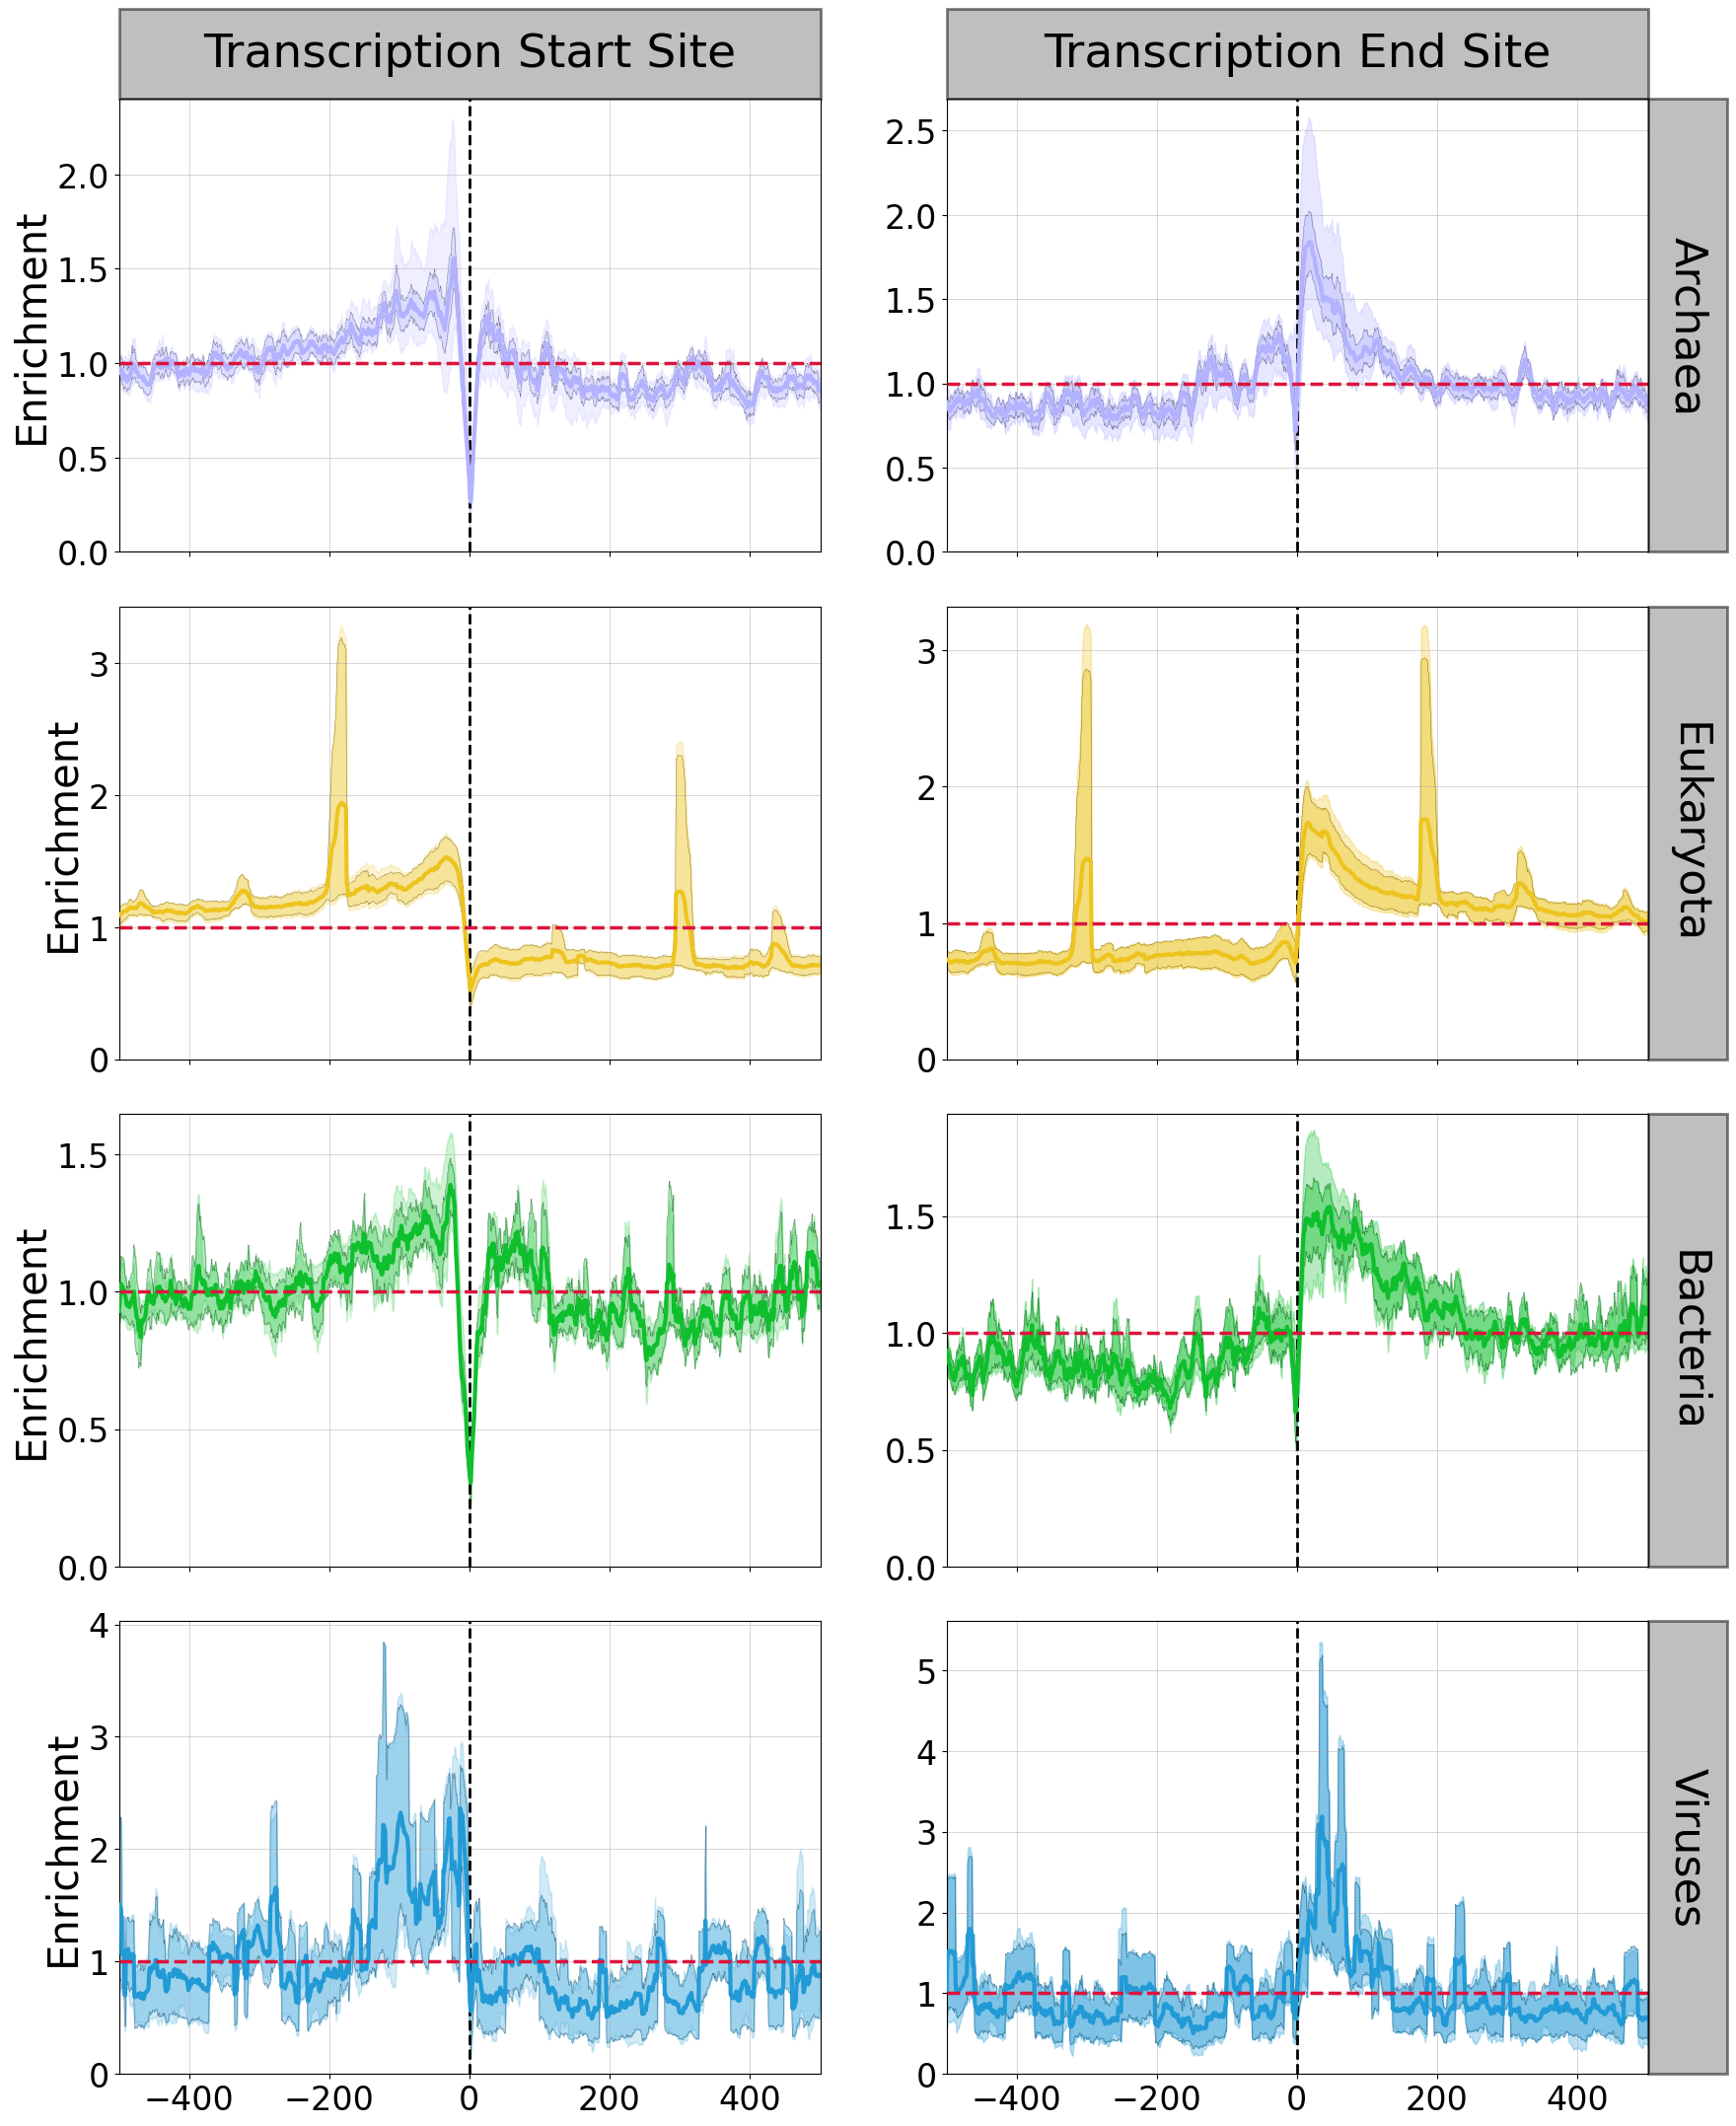

In [24]:
from matplotlib.pyplot import Rectangle
from scipy.stats import ks_2samp
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

density = Path("/storage/group/izg5139/default/nicole/STR_RTR/coverage/enrichment_out/mode_density/domain_bootstrap/").resolve()
assert density.is_dir()
kolmogorov_tests = dict()
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(20, 26))
plt.subplots_adjust(wspace=0.18, hspace=0.12)
kolmogorov_tests = dict()
linewidth = 3.0
window_size = 500

first_level = "species_taxid"
second_level = "family"
third_level = "class"
for idx, phylum in enumerate(["Archaea", "Eukaryota", "Bacteria", "Viruses"]):
    # enrichment_bootstrap_alpha_0.05.TES.polarity.domain.Archaea.csv
    df = pd.read_csv(density.joinpath(f"enrichment_bootstrap_alpha_0.05.TSS.density.domain.{phylum}.csv"))\
                    .query(f"biotype == '.'")
    cols = list(map(str,range(-window_size, window_size+1)))
    tss_template = df.query("sru == 'generic'")
    
    tss_template_mean = tss_template.query(f"statistic == 'average' & bootstrap_level == '{first_level}'")[cols].values[0]
    tss_template_ci_lower = tss_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{first_level}'")[cols].values[0]
    tss_template_ci_upper = tss_template.query(f"statistic == 'upperCI' & bootstrap_level == '{first_level}'")[cols].values[0]

    tss_template_ci_lower_second_layer = tss_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    tss_template_ci_upper_second_layer = tss_template.query(f"statistic == 'upperCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    
    # tss_template_ci_lower_third_layer = tss_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{third_level}'")[cols].values[0]
    # tss_template_ci_upper_third_layer = tss_template.query(f"statistic == 'upperCI' & bootstrap_level == '{third_level}'")[cols].values[0]
    
    df = pd.read_csv(density.joinpath(f"enrichment_bootstrap_alpha_0.05.TES.density.domain.{phylum}.csv"))\
                    .query(f"biotype == '.'")
    tes_template = df.query("sru == 'generic'")
    tes_template_mean = tes_template.query(f"statistic == 'average' & bootstrap_level == '{first_level}'")[cols].values[0]
    tes_template_ci_lower = tes_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{first_level}'")[cols].values[0]
    tes_template_ci_upper = tes_template.query(f"statistic == 'upperCI' & bootstrap_level == '{first_level}'")[cols].values[0]
    
    tes_template_ci_lower_second_layer = tes_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    tes_template_ci_upper_second_layer = tes_template.query(f"statistic == 'upperCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    
    # kolmogorov_test_TSS = ks_2samp(tss_template_mean, tss_non_template_mean)
    # kolmogorov_test_TES = ks_2samp(tes_template_mean, tes_non_template_mean)
    # kolmogorov_tests[phylum, "TSS"] = kolmogorov_test_TSS
    # kolmogorov_tests[phylum, "TES"] = kolmogorov_test_TES
    
    # TES
    xaxis = range(-window_size, window_size+1)
    ax[idx][0].plot(xaxis, 
            tss_template_mean, 
            color=color_templates['template'][phylum], 
            lw=linewidth, 
            zorder=3)
    ax[idx][0].fill_between(xaxis, 
                        y1=tss_template_ci_lower, 
                        y2=tss_template_ci_upper,
                        color=color_templates['template'][phylum], 
                        alpha=0.3
                    )
    ax[idx][0].plot(xaxis,
                    tss_template_ci_lower,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][0].plot(xaxis,
                    tss_template_ci_upper,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][0].fill_between(xaxis, 
                        y1=tss_template_ci_lower_second_layer, 
                        y2=tss_template_ci_upper_second_layer,
                        color=color_templates['template'][phylum], 
                        alpha=0.2
                    )

    # TES
    ax[idx][1].plot(xaxis, 
            tes_template_mean, 
            color=color_templates['template'][phylum], 
            lw=linewidth, 
            zorder=3)
    ax[idx][1].fill_between(xaxis, 
                        y1=tes_template_ci_lower, 
                        y2=tes_template_ci_upper,
                        color=color_templates['template'][phylum], 
                        alpha=0.4
                    )
    ax[idx][1].plot(xaxis,
                    tes_template_ci_lower,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][1].plot(xaxis,
                    tes_template_ci_upper,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][1].fill_between(xaxis, 
                        y1=tes_template_ci_lower_second_layer, 
                        y2=tes_template_ci_upper_second_layer,
                        color=color_templates['template'][phylum], 
                        alpha=0.3
                    )
    # ax.legend(handles=[mpatches.Patch(color=color_templates['template'][domain], label='Template'),
    #                   mpatches.Patch(color=color_templates['non-template'][domain], label='Non-template')
    #                  ], loc=0
    #         )
    
    def _modify_axis(ax, transcription_site):
        # xticks = ax.get_xticks()
        # ax.set_xticks(range(0, len(xticks), 100))
        if transcription_site == "start":
            # ax.set_ylabel("")
            ax.set_ylabel("Enrichment")
        else:
            ax.set_ylabel("")
    
        ax.set_ylim(ymin=0)
        ax.set_xlim(xmin=-window_size, xmax=window_size+1)
        ax.yaxis.label.set_size(30)
        ax.xaxis.label.set_size(21)
        ax.tick_params(axis="both", which="major", labelsize=24)
        if idx != 3:
            ax.set_xticklabels([])
        ax.grid(True, which='both', axis='x') 
        ax.grid(axis="both", lw=0.4, alpha=0.6, zorder=0)
        ax.grid(axis="both", lw=0.6, alpha=0.6, zorder=0)
        ax.axvline(0, linestyle='--', color='black', lw=2.0)
        ax.axhline(1.0, linestyle='--', color='crimson', lw=2.5, zorder=5)
        return ax
    
    ax[idx][0] = _modify_axis(ax[idx][0], transcription_site="start")
    ax[idx][1] = _modify_axis(ax[idx][1], transcription_site="end")
    
    fig.canvas.draw()
    # Get the bounding box of the second subplot in figure coordinates
    sites = ["Transcription Start Site", "Transcription End Site"]
    for i, site in zip(range(2), sites):
        if idx == 0:
            bbox = ax[idx][i].get_position()
            rect_height = 0.035 # Height of the rectangle relative to figure
            rect_bottom = bbox.y1  # Bottom of the rectangle aligns with the top of the subplot
            rect_left = bbox.x0  # Left aligns with the subplot
            rect_width = bbox.x1 - bbox.x0  # Width matches the subplot
            
            # Add rectangle
            fig.patches.append(Rectangle((rect_left, rect_bottom), rect_width, rect_height,
                                         edgecolor="black",
                                         linewidth=2.0,
                                         transform=fig.transFigure, facecolor='gray', alpha=0.5))
            
            # Add title text
            fig.text(rect_left + rect_width / 2, 
                     rect_bottom + rect_height / 2, 
                     # title=site, 
                     s=site,
                     ha='center', 
                     va='center', 
                     color='black', 
                     fontsize=34
                    )
        # Add rectangle
        if i == 1:
            bbox = ax[idx][i].get_position()
            rect_width = 0.04  # Narrow width for a vertical bar
            rect_left = bbox.x1  # Align to the right of the y-axis
            rect_height = bbox.y1 - bbox.y0  # Match the subplot height
            rect_bottom = bbox.y0  # Align with the bottom of the subplot
    
            fig.patches.append(Rectangle((rect_left, rect_bottom), 
                                         rect_width, rect_height,
                                         edgecolor="black",
                                         linewidth=2.0,
                                         transform=fig.transFigure, facecolor='gray', alpha=0.5))
            
            # Add title text
            fig.text(rect_left + rect_width / 2, 
                     rect_bottom + rect_height / 2, 
                     s=phylum,
                     ha='center', 
                     va='center', 
                     color='black',
                     rotation=270,
                     fontsize=32)
    
target = Path("../STR_RTR/STR_figures/TSS_TES").resolve()
print(target)
target.mkdir(exist_ok=True, parents=True)
print(f"{target}/STR_TSS_TES_distribution_domains.png")
fig.savefig(f"{target}/STR_TSS_TES_distribution_domains.pdf", dpi=600, transparent=True, bbox_inches="tight")

## Densities in Phylums

In [53]:
assembly_df = pd.read_table("/storage/group/izg5139/default/nicole/STR_RTR/coverage/assembly_summary_with_tree.csv.gz")
phylums = set(assembly_df["phylum"])
phylum_to_domain = dict(zip(assembly_df["phylum"], assembly_df["domain"]))
len(phylums)

/tmp/ipykernel_3580511/1068892093.py:1: DtypeWarning: Columns (13,14,15,25) have mixed types. Specify dtype option on import or set low_memory=False.
  assembly_df = pd.read_table("/storage/group/izg5139/default/nicole/STR_RTR/coverage/assembly_summary_with_tree.csv.gz")


129

In [54]:
phylum_to_domain = dict(zip(assembly_df["phylum"], assembly_df["domain"]))

STR_figures_RTR/STR_TSS_TES_distribution_domains.png


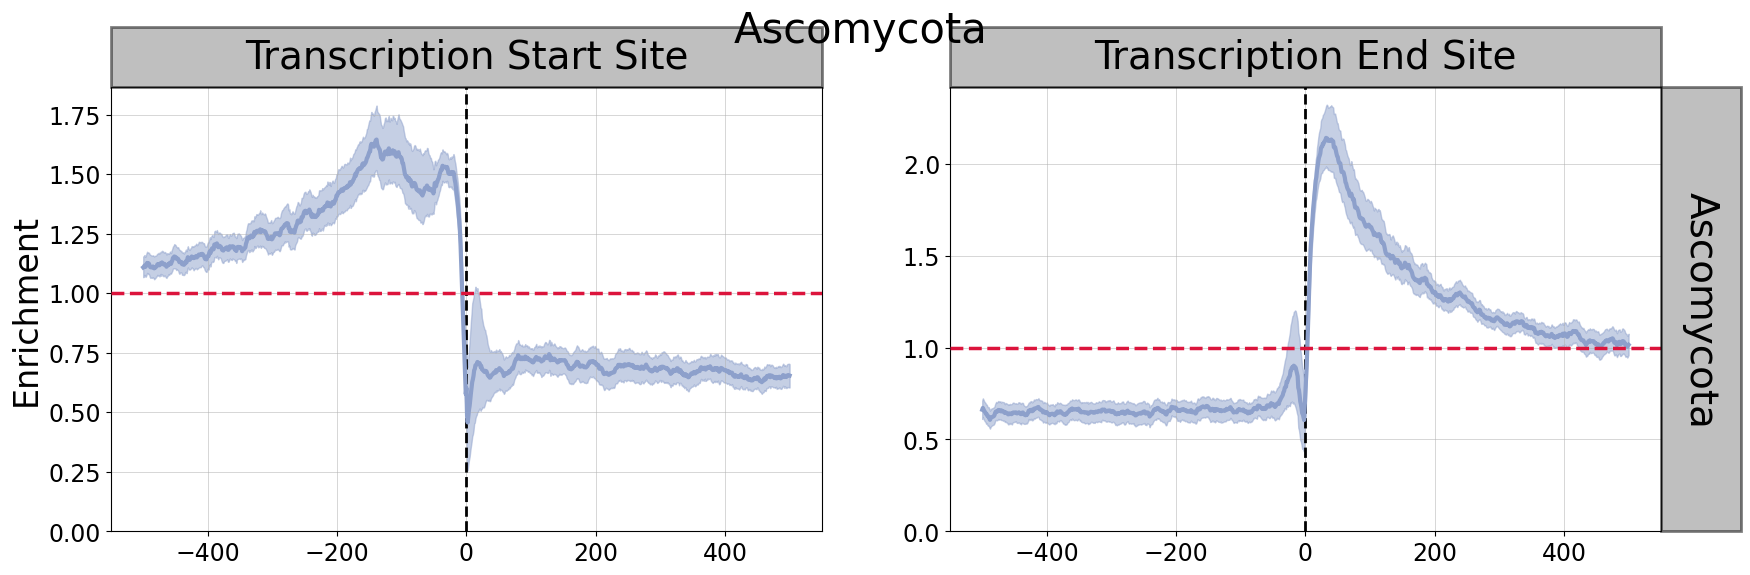

STR_figures_RTR/STR_TSS_TES_distribution_domains.png


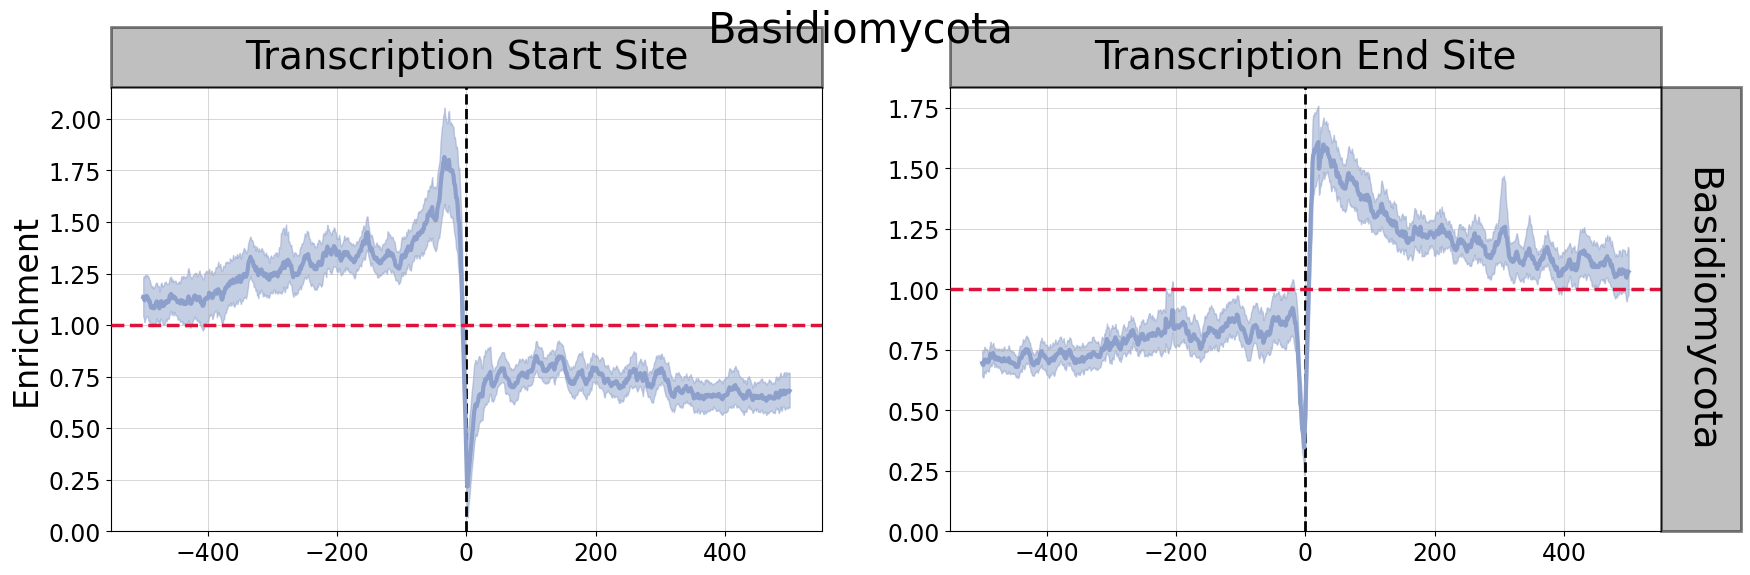

STR_figures_RTR/STR_TSS_TES_distribution_domains.png


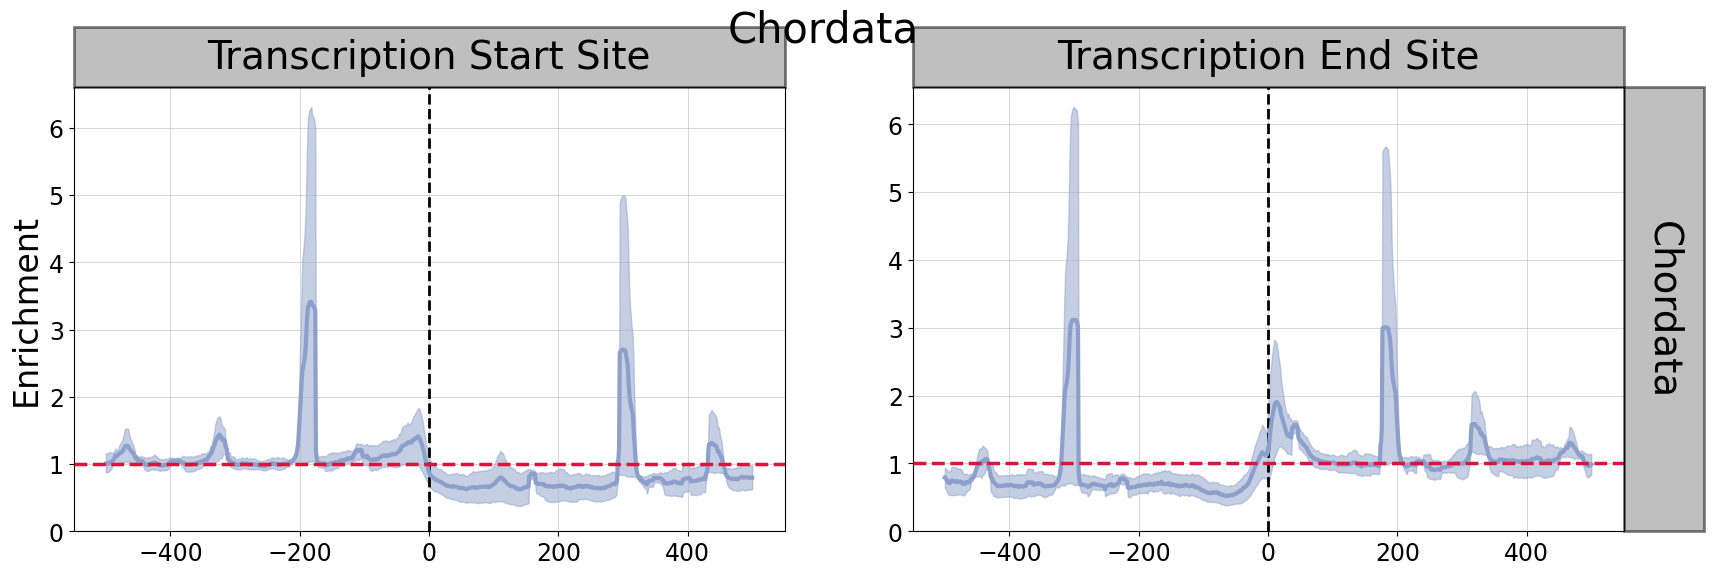

STR_figures_RTR/STR_TSS_TES_distribution_domains.png


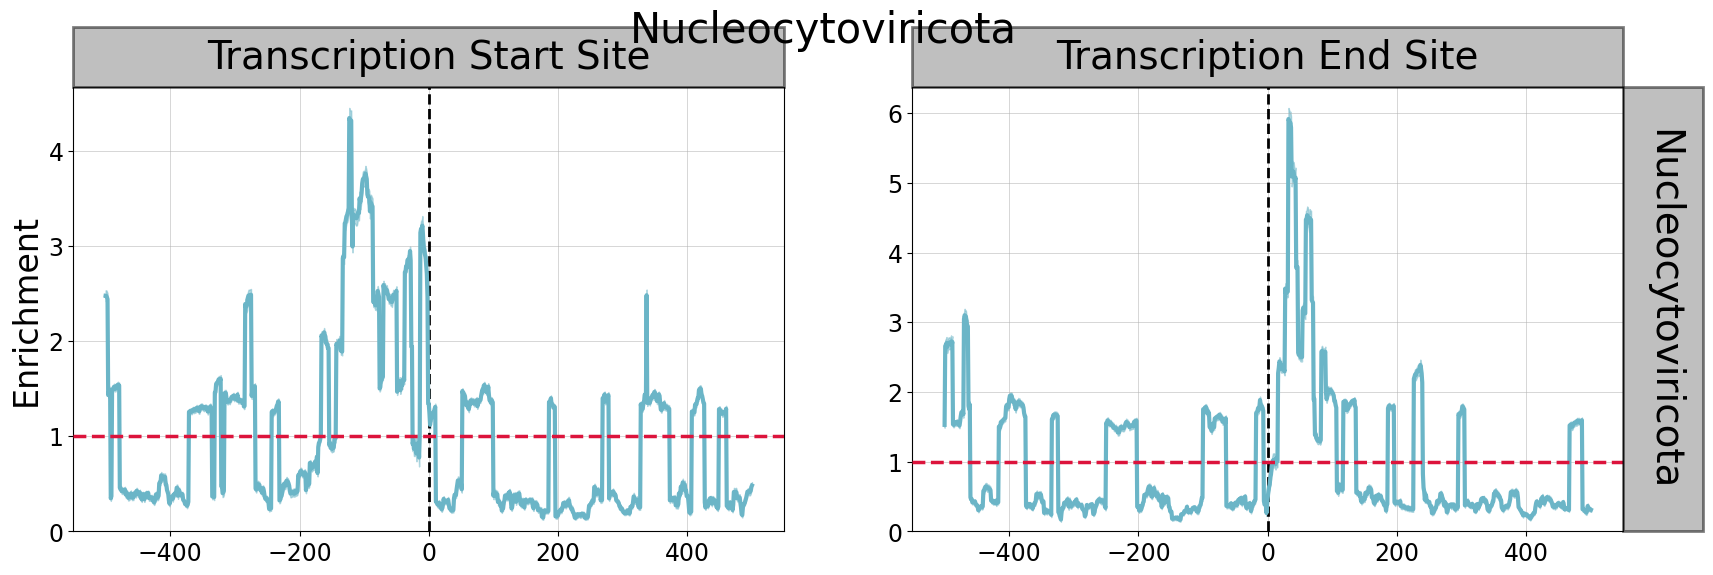

STR_figures_RTR/STR_TSS_TES_distribution_domains.png


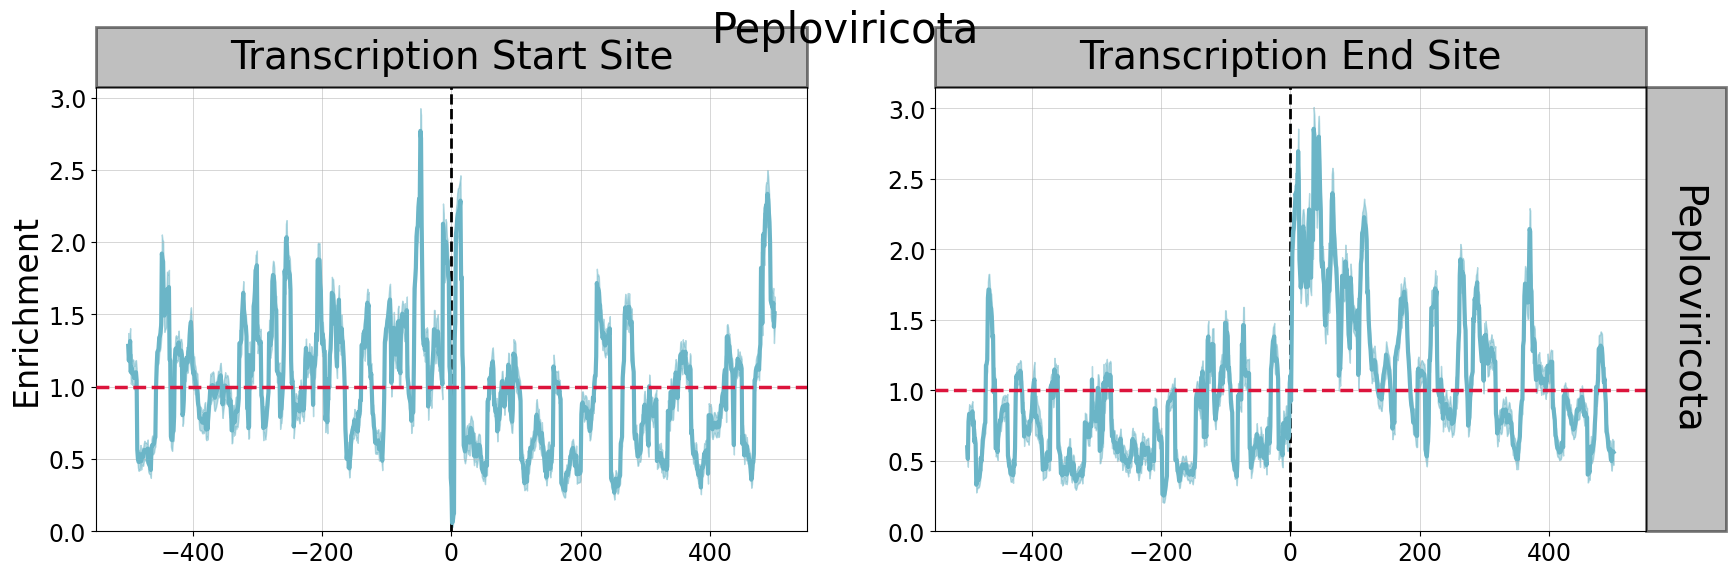

STR_figures_RTR/STR_TSS_TES_distribution_domains.png


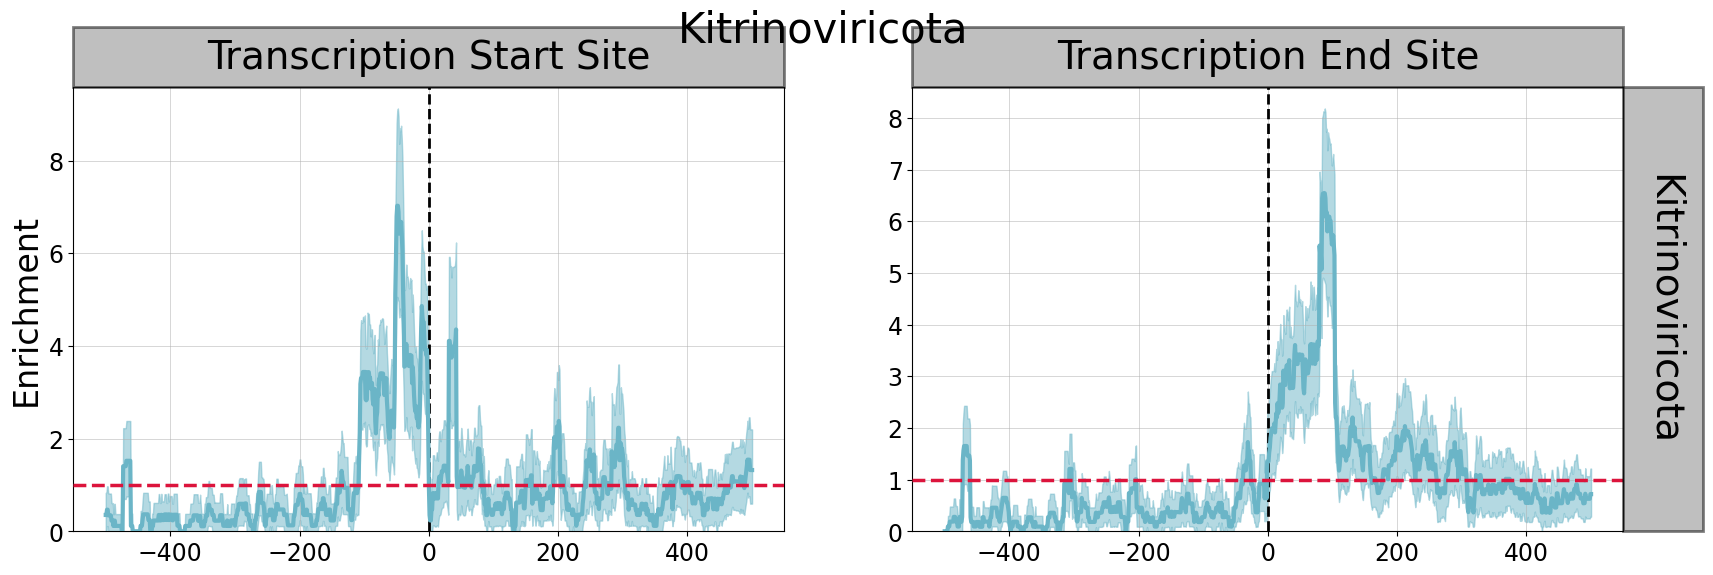

STR_figures_RTR/STR_TSS_TES_distribution_domains.png


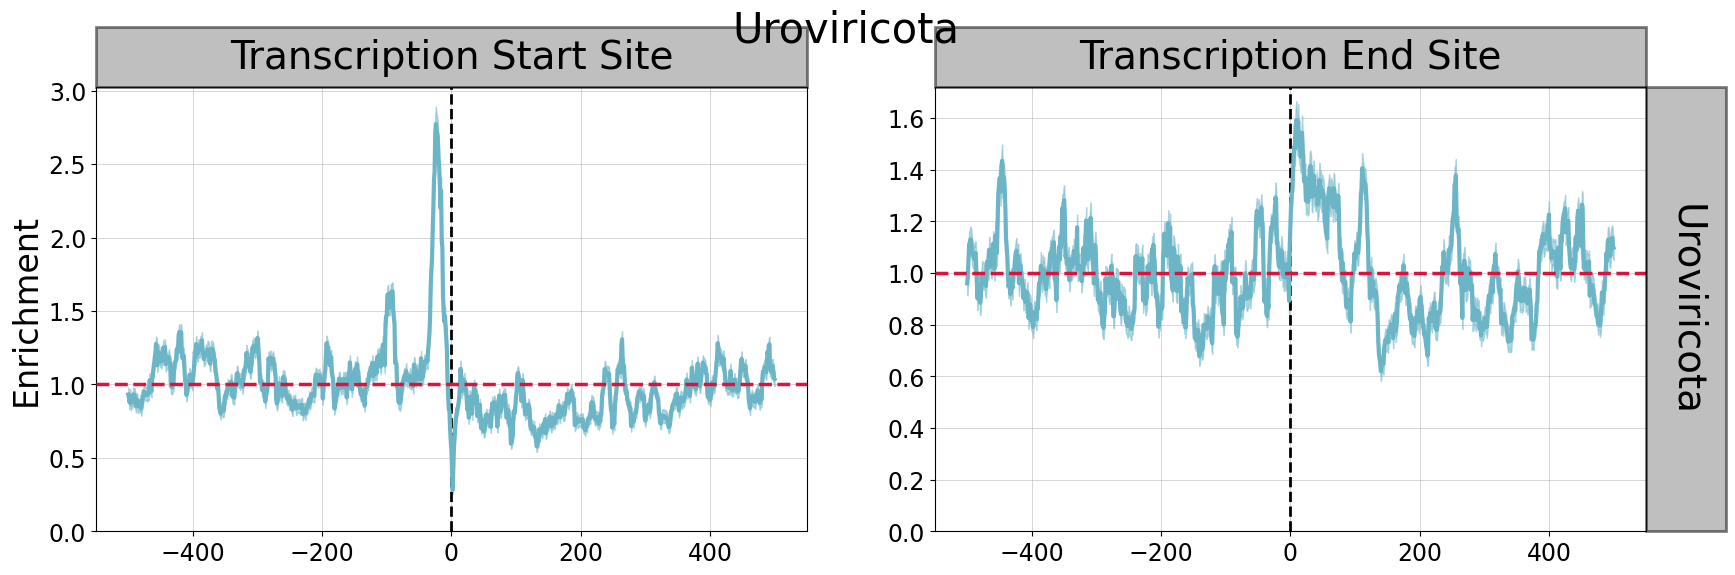

STR_figures_RTR/STR_TSS_TES_distribution_domains.png


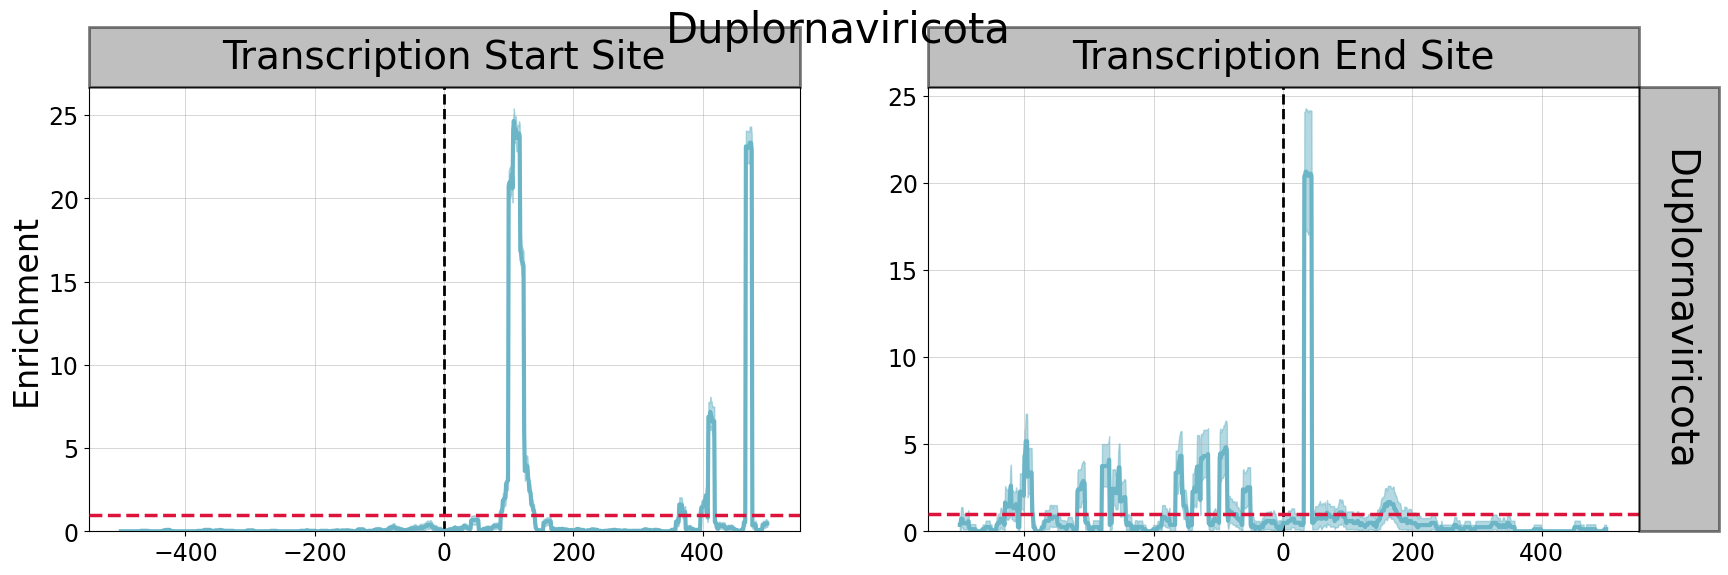

STR_figures_RTR/STR_TSS_TES_distribution_domains.png


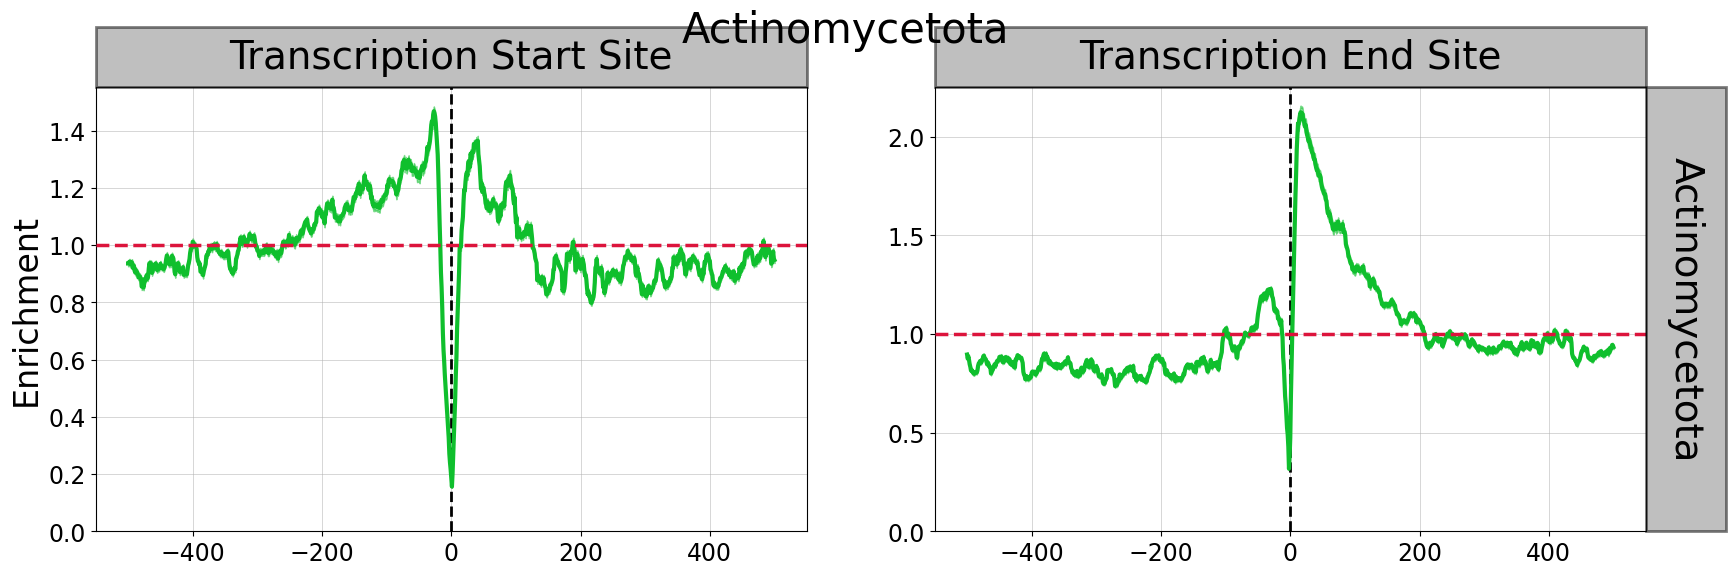

STR_figures_RTR/STR_TSS_TES_distribution_domains.png


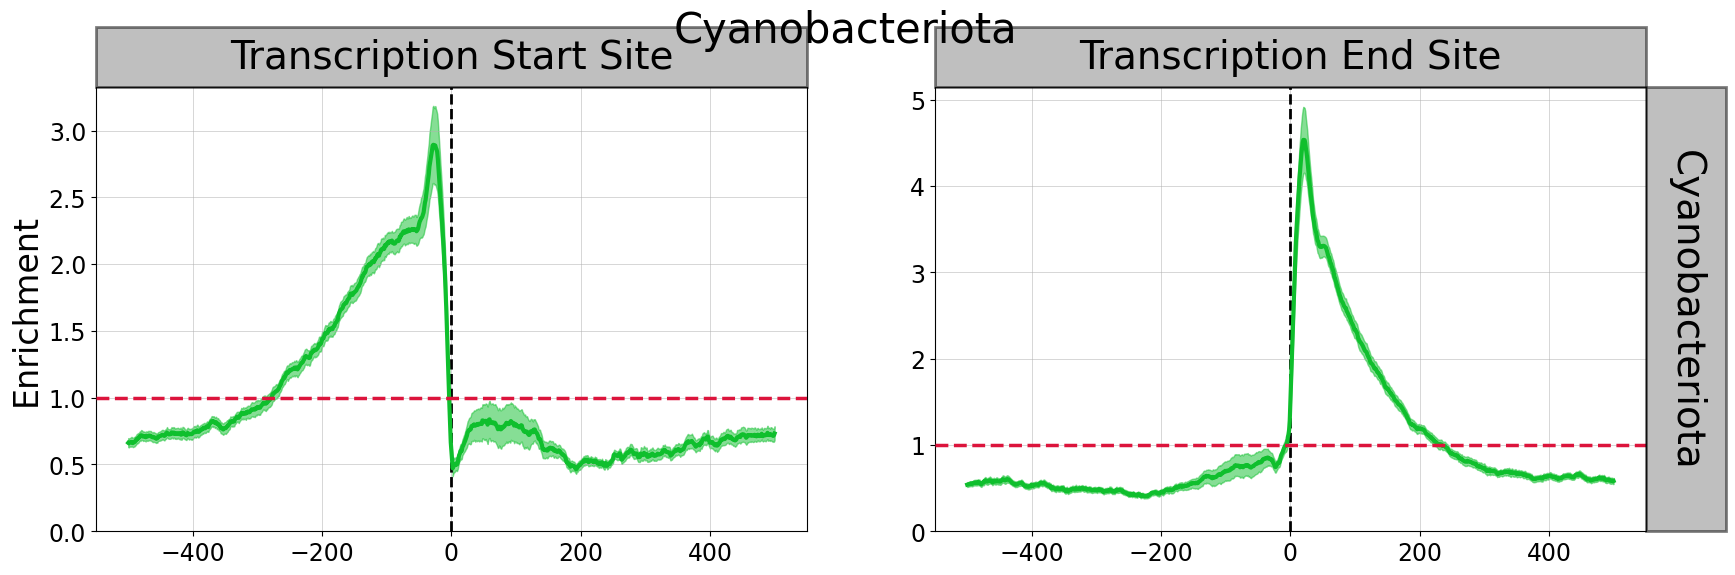

STR_figures_RTR/STR_TSS_TES_distribution_domains.png


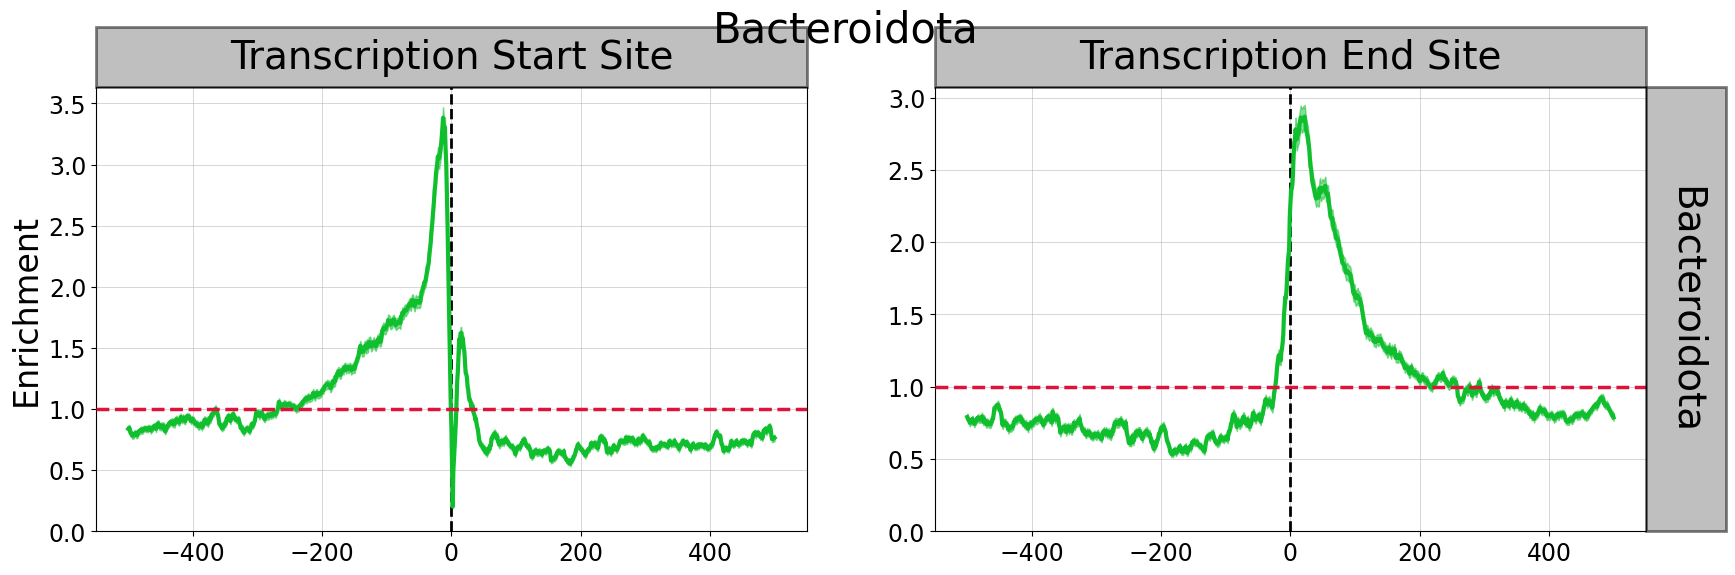

STR_figures_RTR/STR_TSS_TES_distribution_domains.png


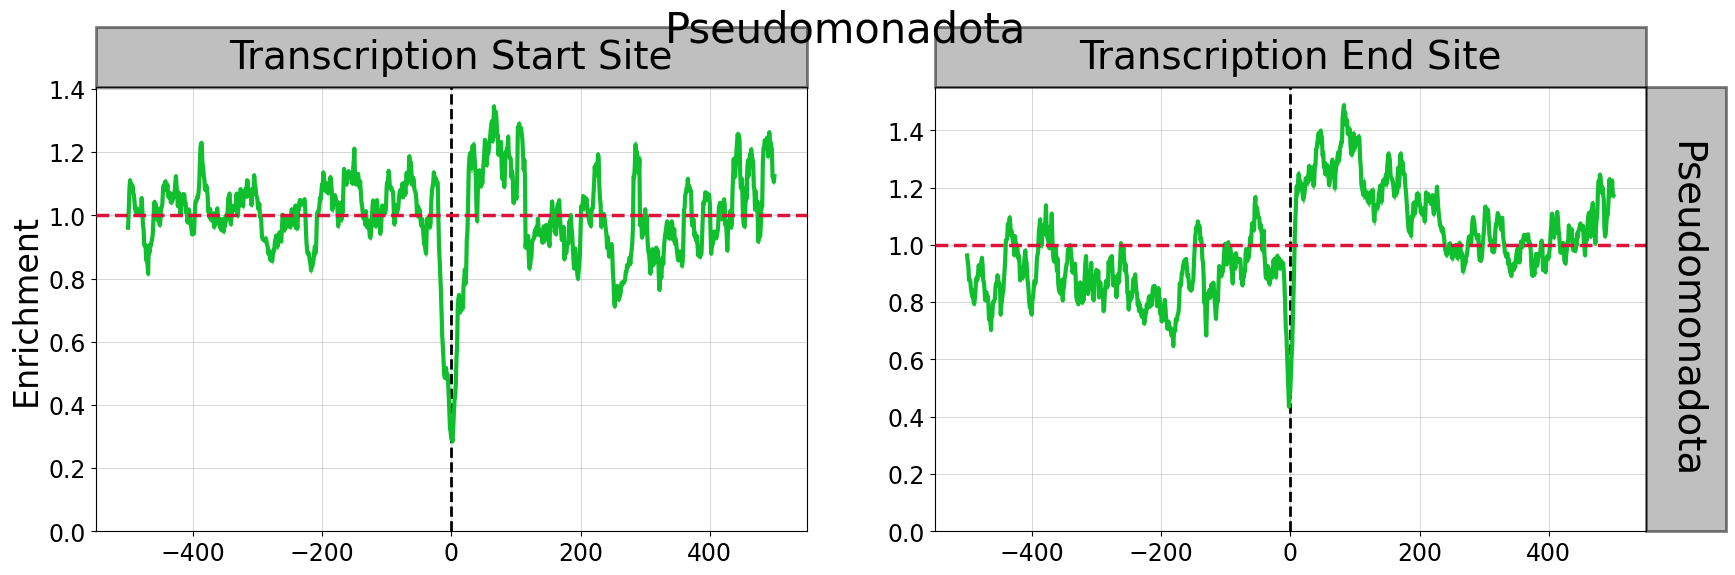

STR_figures_RTR/STR_TSS_TES_distribution_domains.png


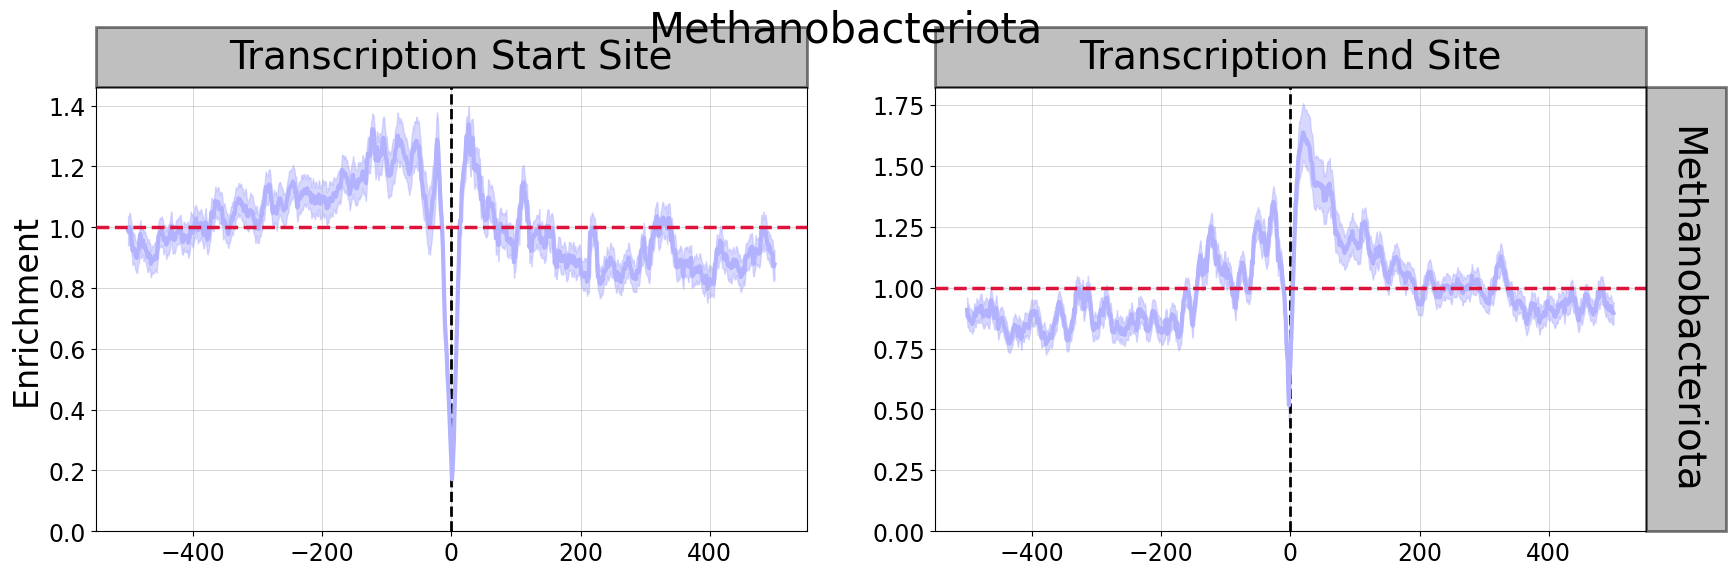

In [17]:
from matplotlib.pyplot import Rectangle
from scipy.stats import ks_2samp
from pathlib import Path

density = Path("/storage/group/izg5139/default/nicole/STR_RTR/coverage/enrichment_out/mode_density/phylum").resolve()
assert density.is_dir()
kolmogorov_tests = dict()

kolmogorov_tests = dict()
linewidth = 3.0
window_size = 500
eukaryotic_phyla = ["Ascomycota", "Basidiomycota", "Chordata"]
viral_phyla = ["Nucleocytoviricota", "Peploviricota", "Kitrinoviricota", "Uroviricota", "Duplornaviricota"]
bacterial_phyla = ["Actinomycetota", "Cyanobacteriota", "Bacteroidota", "Pseudomonadota"]
archaea_phyla = ["Methanobacteriota"]
selected_phyla = eukaryotic_phyla + viral_phyla + bacterial_phyla + archaea_phyla

for idx, phylum in enumerate(selected_phyla):
    domain = phylum_to_domain[phylum]
    # enrichment_bootstrap_alpha_0.05.TES.polarity.domain.Archaea.csv
  
    if not density.joinpath(f"enrichment_bootstrap_alpha_0.05.TSS.density.phylum.{phylum}.csv").is_file():
        continue
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
    plt.subplots_adjust(wspace=0.18, hspace=0.12)
    df = pd.read_csv(density.joinpath(f"enrichment_bootstrap_alpha_0.05.TSS.density.phylum.{phylum}.csv"))\
                    .query(f"biotype == '.'")
    
    cols = list(map(str,range(-window_size, window_size+1)))
    tss_template = df.query("sru == 'generic'")
    tss_template_mean = tss_template.query("statistic == 'average'")[cols].values[0]
    tss_template_ci_lower = tss_template.query("statistic == 'lowerCI'")[cols].values[0]
    tss_template_ci_upper = tss_template.query("statistic == 'upperCI'")[cols].values[0]

    
    df = pd.read_csv(density.joinpath(f"enrichment_bootstrap_alpha_0.05.TES.density.phylum.{phylum}.csv"))\
                                    .query(f"biotype == '.'")
    
    tes_template = df.query("sru == 'generic'")
    tes_template_mean = tes_template.query("statistic == 'average'")[cols].values[0]
    tes_template_ci_lower = tes_template.query("statistic == 'lowerCI'")[cols].values[0]
    tes_template_ci_upper = tes_template.query("statistic == 'upperCI'")[cols].values[0]

    # TES
    domain = phylum_to_domain[phylum]
    xaxis = range(-window_size, window_size+1)
    ax[0].plot(xaxis, 
            tss_template_mean, 
            color=color_templates['template'][domain], 
            lw=linewidth, 
            zorder=3)
    ax[0].fill_between(xaxis, 
                        y1=tss_template_ci_lower, 
                        y2=tss_template_ci_upper,
                        color=color_templates['template'][domain], 
                            alpha=0.5
                    )

    # TES
    ax[1].plot(xaxis, 
            tes_template_mean, 
            color=color_templates['template'][domain], 
            lw=linewidth, 
            zorder=3)
    ax[1].fill_between(xaxis, 
                        y1=tes_template_ci_lower, 
                        y2=tes_template_ci_upper,
                        color=color_templates['template'][domain], 
                            alpha=0.5
                      )
    
    # ax.legend(handles=[mpatches.Patch(color=color_templates['template'][domain], label='Template'),
    #                   mpatches.Patch(color=color_templates['non-template'][domain], label='Non-template')
    #                  ], loc=0
    #         )
    fig.suptitle(phylum, fontsize=30)
    plt.subplots_adjust(top=0.85)
    def _modify_axis(ax, transcription_site):
        # xticks = ax.get_xticks()
        # ax.set_xticks(range(0, len(xticks), 100))
        if transcription_site == "start":
            # ax.set_ylabel("")
            ax.set_ylabel("Enrichment")
        else:
            ax.set_ylabel("")
    
        ax.set_ylim(ymin=0)
        
        ax.yaxis.label.set_size(24)
        ax.xaxis.label.set_size(19)
        ax.tick_params(axis="both", which="major", labelsize=17)
        # ax.set_xticklabels([])
        ax.grid(True, which='both', axis='x') 
        ax.grid(axis="both", lw=0.4, alpha=0.6, zorder=0)
        ax.grid(axis="both", lw=0.6, alpha=0.6, zorder=0)
        ax.axvline(0, linestyle='--', color='black', lw=2.0)
        ax.axhline(1.0, linestyle='--', color='crimson', lw=2.5, zorder=5)
        return ax
    
    ax[0] = _modify_axis(ax[0], transcription_site="start")
    ax[1] = _modify_axis(ax[1], transcription_site="end")
    
    fig.canvas.draw()
    # Get the bounding box of the second subplot in figure coordinates
    sites = ["Transcription Start Site", "Transcription End Site"]
    for i, site in zip(range(2), sites):
        bbox = ax[i].get_position()
        rect_height = 0.1 # Height of the rectangle relative to figure
        rect_bottom = bbox.y1  # Bottom of the rectangle aligns with the top of the subplot
        rect_left = bbox.x0  # Left aligns with the subplot
        rect_width = bbox.x1 - bbox.x0  # Width matches the subplot
        
        # Add rectangle
        fig.patches.append(Rectangle((rect_left, rect_bottom), rect_width, rect_height,
                                     edgecolor="black",
                                     linewidth=2.0,
                                     transform=fig.transFigure, facecolor='gray', alpha=0.5))
        
        # Add title text
        fig.text(rect_left + rect_width / 2, 
                 rect_bottom + rect_height / 2, 
                 # title=site, 
                 s=site,
                 ha='center', 
                 va='center', 
                 color='black', 
                 fontsize=28
                )
        # Add rectangle
        if i == 1:
            bbox = ax[i].get_position()
            rect_width = 0.04  # Narrow width for a vertical bar
            rect_left = bbox.x1  # Align to the right of the y-axis
            rect_height = bbox.y1 - bbox.y0  # Match the subplot height
            rect_bottom = bbox.y0  # Align with the bottom of the subplot
    
            fig.patches.append(Rectangle((rect_left, rect_bottom), 
                                         rect_width, rect_height,
                                         edgecolor="black",
                                         linewidth=2.0,
                                         transform=fig.transFigure, facecolor='gray', alpha=0.5))
            
            # Add title text
            fig.text(rect_left + rect_width / 2, 
                     rect_bottom + rect_height / 2, 
                     s=phylum,
                     ha='center', 
                     va='center', 
                     color='black',
                     rotation=270,
                     fontsize=28)


    target = Path("STR_figures_RTR")
    target.mkdir(exist_ok=True, parents=True)
    print(f"{target}/STR_TSS_TES_distribution_domains.png")
    fig.savefig(f"{target}/STR_TSS_TES_distribution_phylum_{phylum}.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    # fig.suptitle(phylum, fontsize=28)

/tmp/ipykernel_3580511/2895821294.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(loc=0)


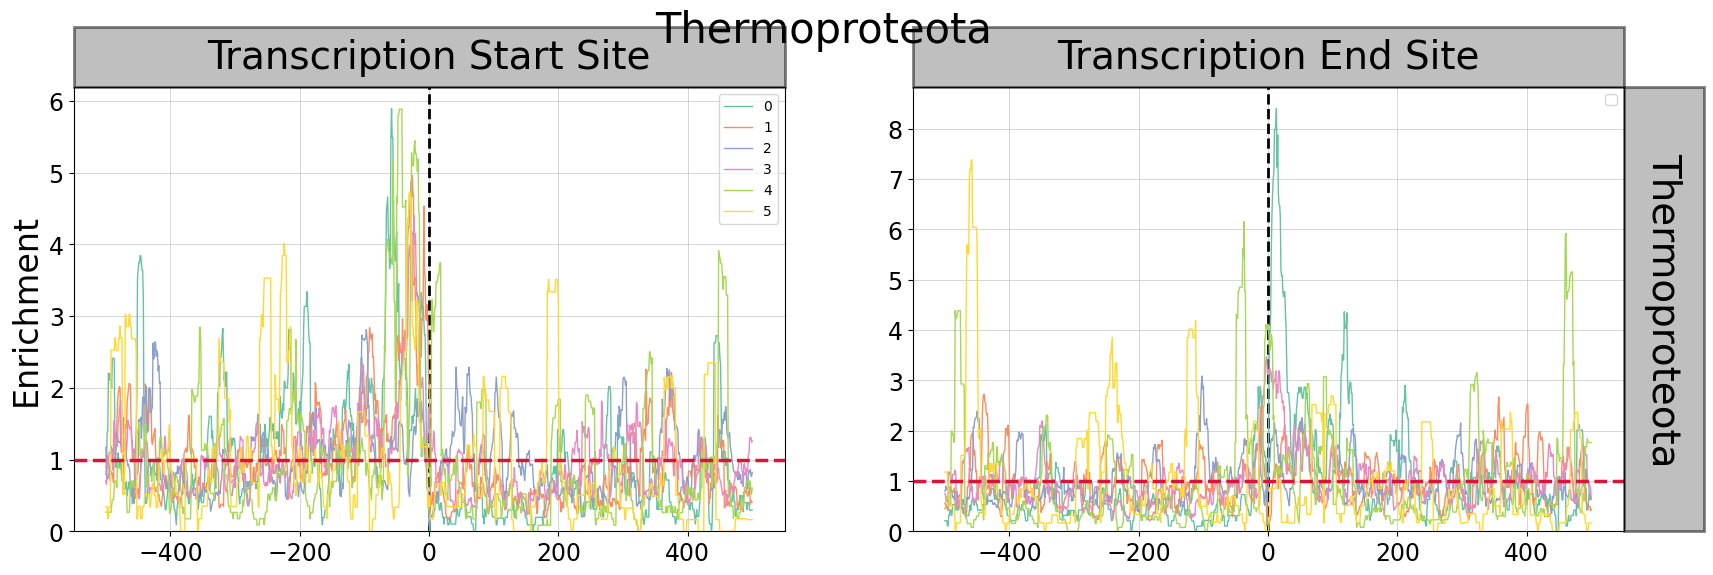

/tmp/ipykernel_3580511/2895821294.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(loc=0)


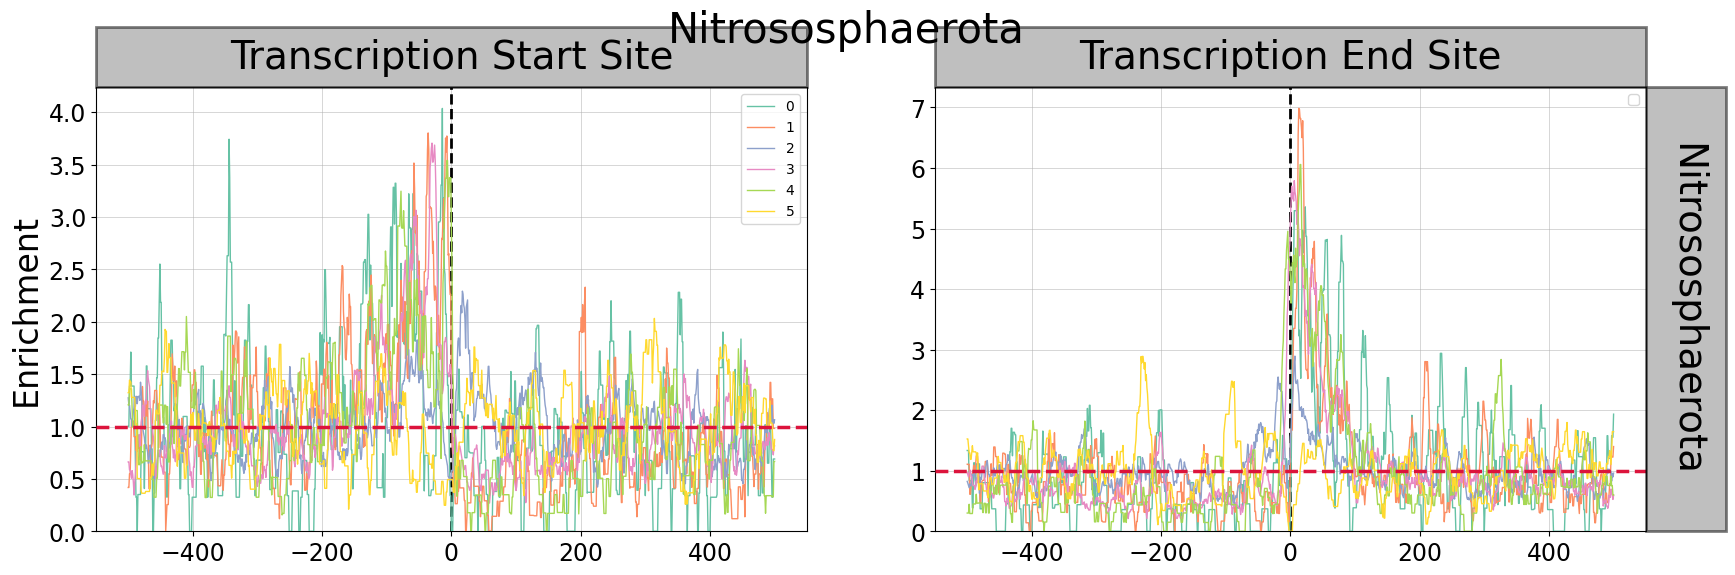

/tmp/ipykernel_3580511/2895821294.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(loc=0)


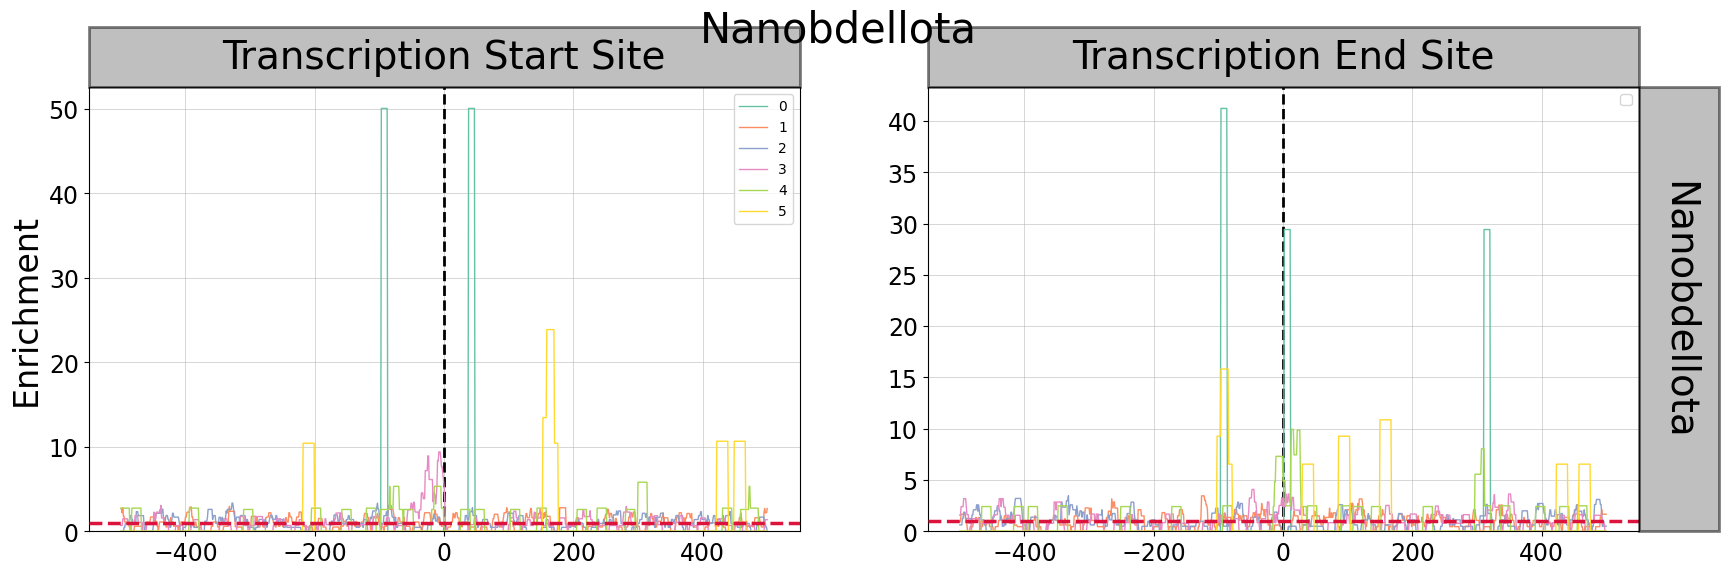

/tmp/ipykernel_3580511/2895821294.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(loc=0)


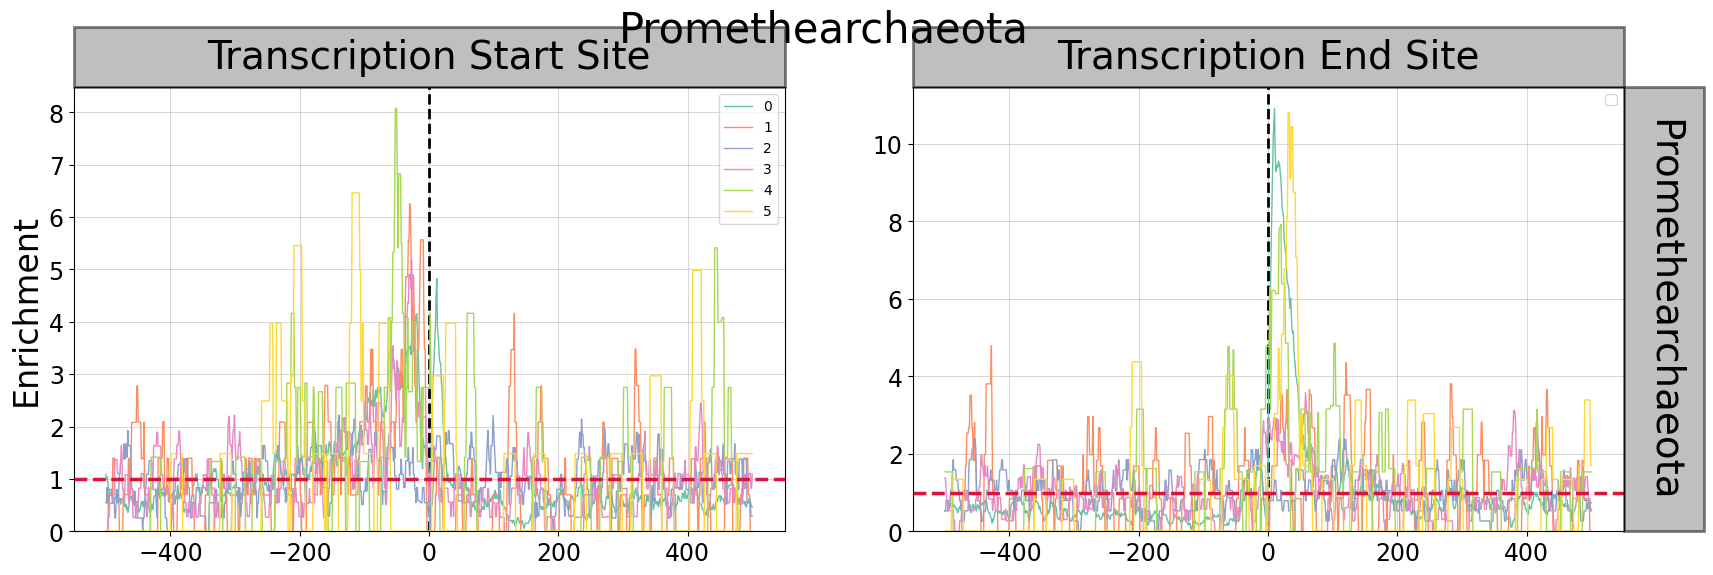

/tmp/ipykernel_3580511/2895821294.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(loc=0)


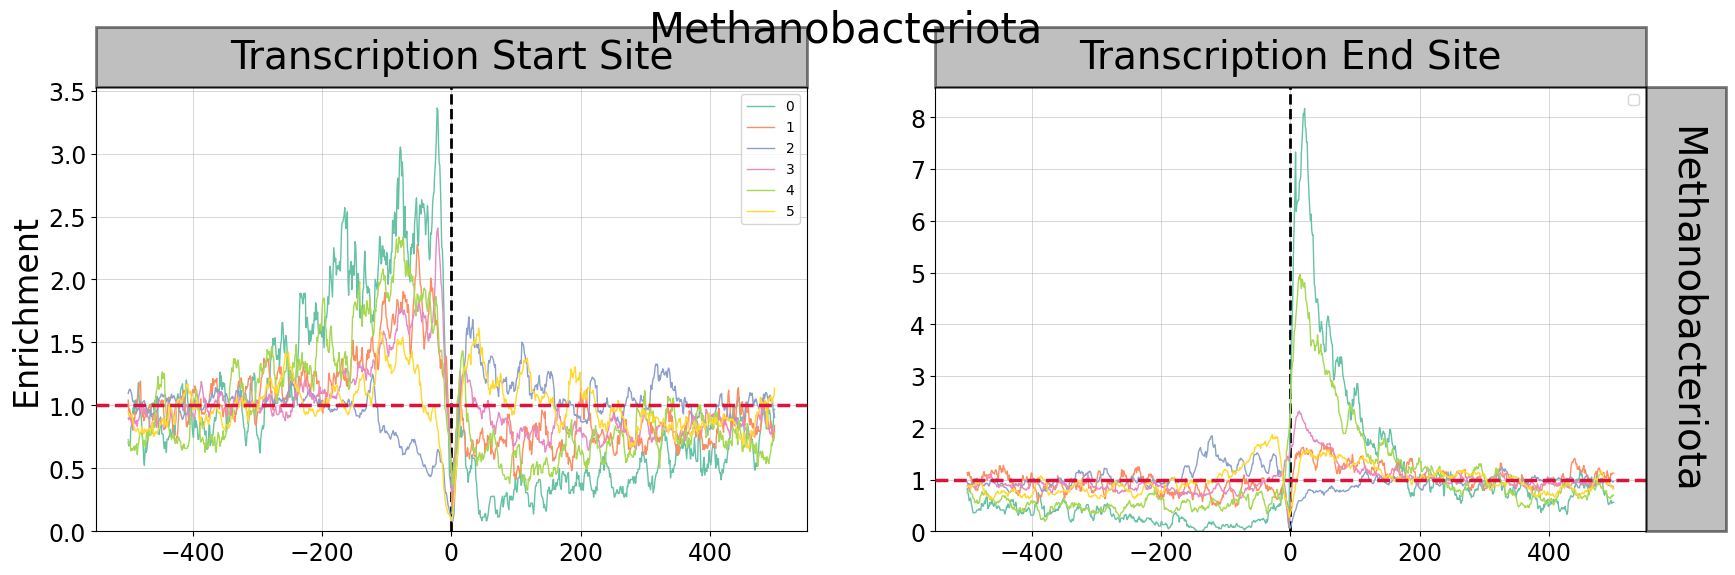

/tmp/ipykernel_3580511/2895821294.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(loc=0)


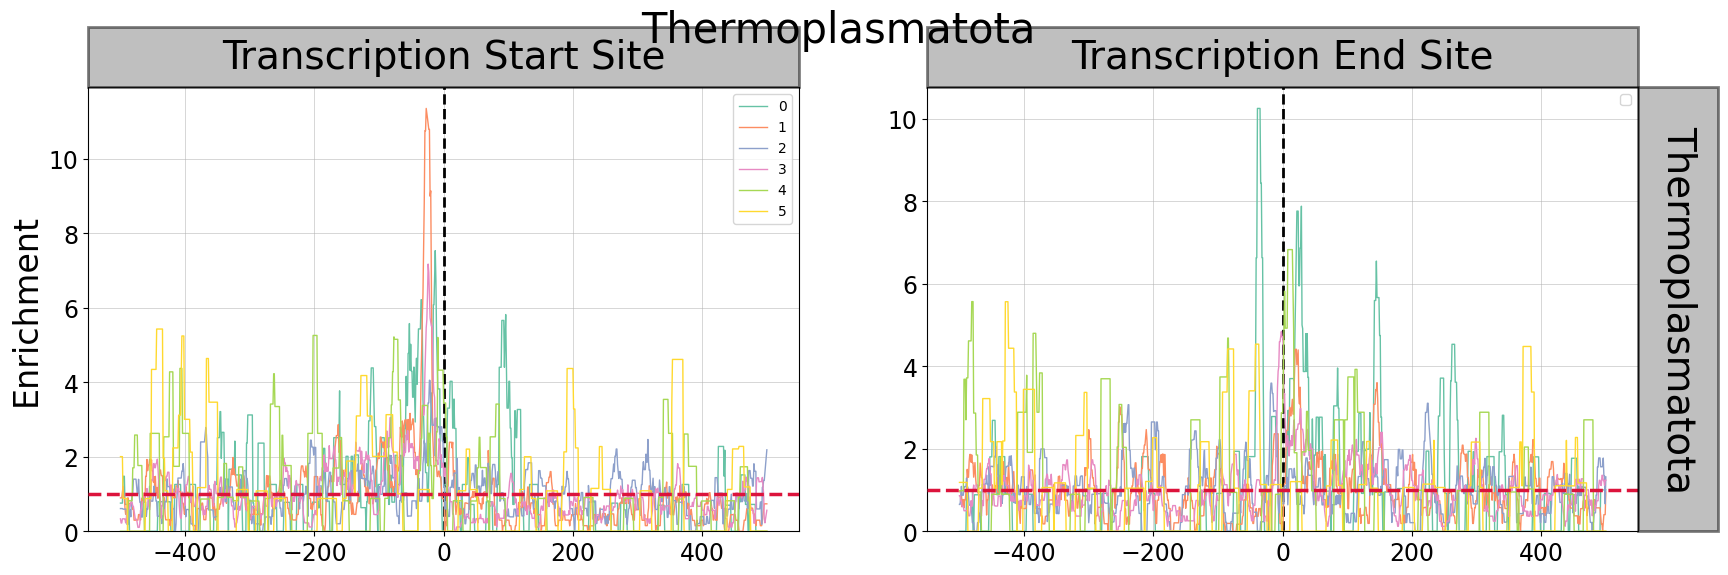

In [58]:
from matplotlib.pyplot import Rectangle
from scipy.stats import ks_2samp
from pathlib import Path

density = Path("/storage/group/izg5139/default/nicole/STR_RTR/coverage/enrichment_out/mode_density/phylum").resolve()
assert density.is_dir()
kolmogorov_tests = dict()

kolmogorov_tests = dict()
linewidth = 1.0
window_size = 500
eukaryotic_phyla = ["Ascomycota", "Basidiomycota", "Chordata"]
viral_phyla = ["Nucleocytoviricota", "Peploviricota", "Kitrinoviricota", "Uroviricota", "Duplornaviricota"]
bacterial_phyla = ["Actinomycetota", "Cyanobacteriota", "Bacteroidota", "Pseudomonadota"]
archaea_phyla = ["Methanobacteriota"]
selected_phyla = eukaryotic_phyla + viral_phyla + bacterial_phyla + archaea_phyla


partition_values = list(map(str, range(1, 7)))
for idx, phylum in enumerate(phylums):
    domain = phylum_to_domain[phylum]

    if domain != "Archaea":
        continue
    # enrichment_bootstrap_alpha_0.05.TES.polarity.domain.Archaea.csv
    
    if not density.joinpath(f"enrichment_bootstrap_alpha_0.05.TSS.density.phylum.{phylum}.csv").is_file():
        continue
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
    plt.subplots_adjust(wspace=0.18, hspace=0.12)
    df_TSS = pd.read_csv(density.joinpath(f"enrichment_bootstrap_alpha_0.05.TSS.density.phylum.{phylum}.csv"))\
                    .query(f"biotype == '.'")
       
    df_TES = pd.read_csv(density.joinpath(f"enrichment_bootstrap_alpha_0.05.TES.density.phylum.{phylum}.csv"))\
                                    .query(f"biotype == '.'")
    
    cols = list(map(str,range(-window_size, window_size+1)))
    domain = phylum_to_domain[phylum]
    xaxis = range(-window_size, window_size+1)
    
    for i, partition in enumerate(partition_values):
        tss_template = df_TSS.query(f"sru == '{partition}'")
        tss_template_mean = tss_template.query("statistic == 'average'")[cols].values[0]
        tss_template_ci_lower = tss_template.query("statistic == 'lowerCI'")[cols].values[0]
        tss_template_ci_upper = tss_template.query("statistic == 'upperCI'")[cols].values[0]

 
        tes_template = df_TES.query(f"sru == '{partition}'")
        tes_template_mean = tes_template.query("statistic == 'average'")[cols].values[0]
        tes_template_ci_lower = tes_template.query("statistic == 'lowerCI'")[cols].values[0]
        tes_template_ci_upper = tes_template.query("statistic == 'upperCI'")[cols].values[0]

        # TSS
        ax[0].plot(xaxis, 
                tss_template_mean, 
                # color=color_templates['template'][domain], 
                color=sns.color_palette("Set2")[i],
                lw=linewidth, 
                zorder=3,
                   label=str(i)
                  )
        # ax[0].fill_between(xaxis, 
        #                     y1=tss_template_ci_lower, 
        #                     y2=tss_template_ci_upper,
        #                     color=color_templates['template'][domain], 
        #                         alpha=0.5
        #                 )
    
        # TES
        ax[1].plot(xaxis, 
                tes_template_mean, 
                # color=color_templates['template'][domain], 
                color=sns.color_palette("Set2")[i],

                lw=linewidth, 
                zorder=3)
        # ax[1].fill_between(xaxis, 
        #                     y1=tes_template_ci_lower, 
        #                     y2=tes_template_ci_upper,
        #                     color=color_templates['template'][domain], 
        #                         alpha=0.5
        #                   )
        
    # ax.legend(handles=[mpatches.Patch(color=color_templates['template'][domain], label='Template'),
    #                   mpatches.Patch(color=color_templates['non-template'][domain], label='Non-template')
    #                  ], loc=0
    #         )
    fig.suptitle(phylum, fontsize=30)
    plt.subplots_adjust(top=0.85)
    for i in range(2):
        ax[i].legend(loc=0)
    def _modify_axis(ax, transcription_site):
        # xticks = ax.get_xticks()
        # ax.set_xticks(range(0, len(xticks), 100))
        if transcription_site == "start":
            # ax.set_ylabel("")
            ax.set_ylabel("Enrichment")
        else:
            ax.set_ylabel("")
    
        ax.set_ylim(ymin=0)
        
        ax.yaxis.label.set_size(24)
        ax.xaxis.label.set_size(19)
        ax.tick_params(axis="both", which="major", labelsize=17)
        # ax.set_xticklabels([])
        ax.grid(True, which='both', axis='x') 
        ax.grid(axis="both", lw=0.4, alpha=0.6, zorder=0)
        ax.grid(axis="both", lw=0.6, alpha=0.6, zorder=0)
        ax.axvline(0, linestyle='--', color='black', lw=2.0)
        ax.axhline(1.0, linestyle='--', color='crimson', lw=2.5, zorder=5)
        return ax
    
    ax[0] = _modify_axis(ax[0], transcription_site="start")
    ax[1] = _modify_axis(ax[1], transcription_site="end")
    
    fig.canvas.draw()
    # Get the bounding box of the second subplot in figure coordinates
    sites = ["Transcription Start Site", "Transcription End Site"]
    for i, site in zip(range(2), sites):
        bbox = ax[i].get_position()
        rect_height = 0.1 # Height of the rectangle relative to figure
        rect_bottom = bbox.y1  # Bottom of the rectangle aligns with the top of the subplot
        rect_left = bbox.x0  # Left aligns with the subplot
        rect_width = bbox.x1 - bbox.x0  # Width matches the subplot
        
        # Add rectangle
        fig.patches.append(Rectangle((rect_left, rect_bottom), rect_width, rect_height,
                                     edgecolor="black",
                                     linewidth=2.0,
                                     transform=fig.transFigure, facecolor='gray', alpha=0.5))
        
        # Add title text
        fig.text(rect_left + rect_width / 2, 
                 rect_bottom + rect_height / 2, 
                 # title=site, 
                 s=site,
                 ha='center', 
                 va='center', 
                 color='black', 
                 fontsize=28
                )
        # Add rectangle
        if i == 1:
            bbox = ax[i].get_position()
            rect_width = 0.04  # Narrow width for a vertical bar
            rect_left = bbox.x1  # Align to the right of the y-axis
            rect_height = bbox.y1 - bbox.y0  # Match the subplot height
            rect_bottom = bbox.y0  # Align with the bottom of the subplot
    
            fig.patches.append(Rectangle((rect_left, rect_bottom), 
                                         rect_width, rect_height,
                                         edgecolor="black",
                                         linewidth=2.0,
                                         transform=fig.transFigure, facecolor='gray', alpha=0.5))
            
            # Add title text
            fig.text(rect_left + rect_width / 2, 
                     rect_bottom + rect_height / 2, 
                     s=phylum,
                     ha='center', 
                     va='center', 
                     color='black',
                     rotation=270,
                     fontsize=28)


    target = Path("STR_figures_RTR").joinpath("phylums")
    target.mkdir(exist_ok=True, parents=True)
    # fig.savefig(f"{target}/MR_TSS_TES_distribution_phylum_{phylum}_partitioned.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    # fig.suptitle(phylum, fontsize=28)